# Fisher-vs-MCMC cross-check: PFS $P_\ell + B_0$ + DESI DR2 BAO + BBN+$n_s$ ($\Lambda$CDM)

BlackJAX posterior on the **same forecast likelihood** as
`fisher_joint_PFS_BAO_BBN_ns_LCDM.ipynb`, to test whether the Fisher
(Gaussian) forecast is consistent with the full posterior. The exact likelihood is the
ground-truth definition and the smoke gate; production samples a Taylor surrogate of it
(see "Production sampling" below).

**Setup (matches the Fisher notebook exactly):**
- PFS full-shape $P_\ell(k) + B_0$ (7 bins, AP), DESI DR2 BAO, BBN + $n_{s,10}$ + EFT/stochastic priors.
- **Noiseless mock**: the "data" is the fiducial theory vector, so the posterior is centred at the
  fiducial and its width/shape directly test the Fisher approximation.
- **Sample the full varied block** (cosmology + per-bin EFT/survey params, minus the fixed ones) —
  the same block the Fisher marginalises — then compare the marginal cosmology posterior to the
  Fisher cosmology block.
- **EFT/stochastic priors: the DESI DR1-reanalysis spec** (`desi_dr1_reanalysis_2511_20757`,
  arXiv:2511.20757 Table I) with runtime $A_{\rm AP}A_{\rm amp}$ rescaling and the correlated
  per-bin counterterm block — see the prior section below for the mean-vs-mode caveat.
  **The same spec drives the comparison Fisher**, so the sampled target and the red ellipses
  below are the same statistical model (one documented asymmetry: the diagonal-only Fisher
  machinery consumes the *marginal* widths of the correlated counterterm block).
- **Whitening** uses the legacy-spec prior-included Fisher purely as the **sampling geometry**
  (an affine reparametrisation: the MH proposal, and the NUTS preconditioner before adaptation).
  It enters neither the target nor the comparison Fisher.

> **Runtime and committed state.** `SMOKE_TEST=True` — the committed execution — runs the
> EXACT per-bin path (~5.7 s per forward evaluation; a 60-step RWMH gate in ~6 min) plus a
> seconds-scale NUTS shakedown on the surrogate. `SMOKE_TEST=False` runs production NUTS on
> the Taylor surrogate: dense algebra with no theory evaluation per step, so **minutes**
> rather than the ~10 days the exact path would need for the same chain.
> **The production branch has never been executed end to end in any committed state of this
> notebook** — every stored output below is from the smoke path, so the comparison table and
> corner plot are noise-dominated pipeline checks, not science results.


In [1]:
from functools import partial
import os
import time

N_THREADS = os.cpu_count() or 1
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[_v] = str(N_THREADS)
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-jaxptpolypol")

import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
plt.rcParams.update({
    "text.usetex": True, "font.family": "sans-serif",
    "font.sans-serif": "Computer Modern", "font.size": 22})

import numpy as np
from tqdm.auto import tqdm

import jax
jax.config.update("jax_enable_x64", True)

# Persistent XLA compilation cache: repeated notebook runs reuse compiled graphs
import pathlib as _pathlib
jax.config.update("jax_compilation_cache_dir", str(_pathlib.Path.home() / ".jax_xla_cache"))
jax.config.update("jax_persistent_cache_min_compile_time_secs", 10)
import jax.numpy as jnp
from jax.scipy.linalg import inv

from ps_1loop_jax import background as bg

from jaxptpolypol import (
    split_marginal_indices, bin_lin_slices,
    make_marginal_log_posterior_perbin,
)
from jaxptpolypol.desi_priors import (
    load_desi_prior_spec, make_desi_prior_fns, make_lcdm_rescaling_fns,
    build_prior_sigmas_from_desi_spec,
)
from jaxptpolypol.model import BispectrumTreeModel, CosmoEmulator, PS1LoopModel
from jaxptpolypol.params import CosmoParams, FullShapeSurveyParams, pack_joint_params
from jaxptpolypol.theory import (
    build_bispectrum_triangles_from_k_grid, compute_fiducial_distances,
    make_gaussian_joint_covariance_fn, make_joint_pk_bk_fn,
    make_joint_pk_bk_bin_fn,
)
from jaxptpolypol.bao import (
    load_desi_dr2, bao_fisher_matrix, add_bao_to_fullshape_fisher, make_bao_theory_fn,
)
from jaxptpolypol.priors import load_prior_spec, build_prior_sigmas_from_spec
from jaxptpolypol.inference import (
    fisher_matrix, marginalize_fisher, marginalized_fisher_block,
    fixed_and_varied_indices, gaussian_prior_fisher, build_prior_sigmas,
)
from jaxptpolypol.plotting import plot_contours, plot_Gaussian
from jaxptpolypol.chain_analysis import (
    make_fullshape_spec, packed_samples_to_dict, scalar_summary_packed, plot_trace,
)
from jaxptpolypol.sampler import (
    make_transform, make_cholesky_transform, make_full_params_fn, make_gaussian_log_prior,
    make_log_posterior, run_nuts, run_rwmh, run_rwmh_python, samples_to_physical,
)


## Configuration (mirrors the Fisher notebook)

In [2]:
# ── Unified fiducial cosmology (Planck 2018 TT,TE,EE+lowE+lensing+BAO) ──
FIDUCIAL = {
    'ombh2': 0.02242, 'omch2': 0.11933, 'logA': 3.047,
    'ns': 0.9665, 'h': 0.6766, 'tau': 0.0561,
}
MNU_FIXED = 0.06  # eV, not varied in LCDM

# ── PFS survey config ──
z_bins   = (0.7,  0.9,  1.1,  1.3,  1.5,  1.8,  2.2)
V_bins   = tuple(v * 1000.**3 for v in (0.59, 0.79, 0.96, 1.09, 1.19, 2.58, 2.71))
knl_bins = (0.52, 0.65, 0.82, 1.02, 1.29, 1.82, 2.88)
n_bar    = (3.06e-4, 9.61e-4, 9.75e-4, 6.54e-4, 3.40e-4, 2.02e-4, 3.51e-4)
n_zbins  = len(z_bins)

# ── Bispectrum / joint P+B config (identical to the Fisher notebook) ──
K_PK_MIN, K_PK_MAX, N_K = 0.02, 0.20, 37
K_BK_MIN, K_BK_MAX = 0.02, 0.08
K_NL_RSD = 0.45
NUM_MU = NUM_PHI = 65
N_GL = 16
BB_POWER_MODEL = 'kaiser'
BACKGROUND_MODE = 'direct'

PFS_EMULATOR = '/Users/nguyenmn/cosmopower-jax-for-pfs/cosmology/jense2024/jense_2023_camb_lcdm/networks/jense_2023_camb_lcdm_Pk_lin.npz'
BAO_DATA_DIR = "../../ext_data/bao_data/desi_bao_dr2"

# ── Forecast (cosmology) basis and priors ──
SHARED_KEYS = ('ombh2', 'omch2', 'logA', 'ns', 'h')
N_SHARED = len(SHARED_KEYS)
SHARED_LABELS = (r'$\omega_b$', r'$\omega_c$', r'$\log A$', r'$n_s$', r'$h$')
FIDUCIAL_SHARED = np.array([FIDUCIAL[k] for k in SHARED_KEYS])
COSMO_PRIORS = {'ombh2': 0.00055, 'ns': 0.042}  # BBN + ns10 (arXiv:2411.12022)
MODEL_TITLE = r'$\Lambda$CDM'

# ── Marginalized-nuisance prior MEANS variant (CONTEXT.md POLICY 2026-08-04) ──
# Forecast default fiducial-centers the theta_lin marginalized-prior means; the
# DESI widths, correlated c0/c2/c4 cov-structure, theta_NL A_AP*A_amp rescaling,
# and the b1 sampling measure are IDENTICAL in both variants -- only means differ.
PRIOR_VARIANT = "fiducial_centered"   # "fiducial_centered" (policy default) | "desi_paper" (Table-I means variant)

# ── MCMC run mode ──
SMOKE_TEST = False   # tiny chain to validate the pipeline end-to-end; set False for production
# PRODUCTION sampling runs gradient-based NUTS on the prior-independent Taylor
# surrogate (validated: DESI-prior gate widths 0.986-1.014 & max |Dcorr| 0.021
# vs Hessian-Fisher; NUTS-on-surrogate R-hat <= 1.0002, 0 divergences; fiducial
# identity surrogate lp0 == exact lp0 == -167.752302 (fiducial_centered default; -172.996046 under the desi_paper means variant)). The exact per-bin RWMH
# (gradient-free MH, arXiv:2511.20757) is retained as the SMOKE gate: NUTS grad
# of the EXACT marginal posterior is a second-order XLA graph that exhausts
# memory, whereas the surrogate body is tiny dense algebra where NUTS is the
# right tool (docs/design/perbin-compile-measurements.md).
NUTS_SEED = 20260731                             # matches scripts/taylor_surrogate_nuts.py
NUTS_SHAKE_WARMUP, NUTS_SHAKE_DRAWS = 100, 200   # smoke-only surrogate NUTS shakedown (seconds)
if SMOKE_TEST:
    # Exact per-bin RWMH smoke gate: at ~5.7 s/step this 60-step chain takes
    # ~6 min end-to-end, plus a seconds-scale surrogate NUTS shakedown.
    NUM_SAMPLES_MH, NUM_BURN_MH, NUM_CHAINS = 60, 10, 1
else:
    # Production NUTS-on-surrogate (taylor_surrogate_nuts.py-validated settings,
    # ~minutes) REPLACES the former 150k-step exact RWMH (~10 days of forward
    # stepping at ~5.7 s/step).
    NUTS_WARMUP, NUTS_DRAWS, NUTS_CHAINS = 1000, 5000, 4


## Emulator, models, fiducial parameters

In [3]:
pklin_emulator = CosmoEmulator(probe='custom_log', emulator_path=PFS_EMULATOR)
ps1loop_model = PS1LoopModel(do_irres=True)
bispectrum_model = BispectrumTreeModel(do_AP=True, k_nl_rsd=K_NL_RSD)

cosmo_dict = {
    'ombh2': FIDUCIAL['ombh2'], 'omch2': FIDUCIAL['omch2'],
    'logA':  FIDUCIAL['logA'],  'ns':    FIDUCIAL['ns'], 'h': FIDUCIAL['h'],
    'z': 0.7, 'A_b': 3.13, 'eta_b': 0.603, 'logT_AGN': 7.8,
}
cosmo = CosmoParams(cosmo_dict)

# ── Bias / counterterm fiducials (arXiv:1907.06666) ──
def b1z(z): return 0.9 + 0.4 * z
def b2z(z): return -0.704 - 0.208 * z + 0.183 * z**2 - 0.00771 * z**3
def bG2z(z): return -(2. / 7.) * (b1z(z) - 1.)
def bGamma3z(z): return (23. / 42.) * (b1z(z) - 1.)
def Dplusz(z):
    return float(bg.growth_factor(
        cosmo_dict['ombh2'], cosmo_dict['omch2'], cosmo_dict['h'], z, mnu=MNU_FIXED))
def c0z(z): return 25. * Dplusz(z)**2
def c2z(z): return 25. * Dplusz(z)**2
def c4z(z): return Dplusz(z)**2

surveys = []
for z, knl, nd in zip(z_bins, knl_bins, n_bar):
    surveys.append(FullShapeSurveyParams(
        shared={'bias': {'b1': b1z(z), 'b2': b2z(z), 'bG2': bG2z(z), 'bGamma3': bGamma3z(z)},
                'stoch': {'P_shot': 1.0}, 'k_nl': knl, 'ndens': nd},
        pk={'ctr': {'c0': c0z(z), 'c2': c2z(z), 'c4': c4z(z), 'cfog': knl**(-4)},
            'stoch': {'a0': 0., 'a2': 0.}},
        bk={'ctr': {'c1': 0.0}, 'stoch': {'B_shot': 1.0, 'A_shot': 1.0}},
    ))
joint_survey_keys = surveys[0].joint_param_keys
packed_params = pack_joint_params(cosmo, surveys)
n_cosmo_params = sum(cosmo.param_sizes)
n_survey_params = len(joint_survey_keys)
Hz_fid, DAz_fid = compute_fiducial_distances(cosmo, z_bins)
print(f"Packed params: {packed_params.shape[0]} ({n_cosmo_params} cosmo + {n_survey_params}x{n_zbins} survey)")

Tried to load pickle file from pre-trained model, but failed.
This usually means that you have TF>=2.14, or that you are loading a model that was trained on PCA but loaded with the log (or viceversa), or that you are loading a non-standard model from the cosmopower-organization repo.
Falling back to the dictionary, in case this also fails or does not output the right shape make sure you ran the `convert_tf214.py` script, and that a `.npz` file exists among the trained models, and that you ran `pip install .`. Also make sure that you are asking for the right probe between `custom_log` and `custom_pca`.


Packed params: 121 (9 cosmo + 16x7 survey)


## Joint P+B theory, covariance, and the data Fisher

In [4]:
# Single source of truth for the theory configuration: the monolithic joint_fn
# (used for the mock data vector and the Fisher) and the per-bin theory closures
# in the likelihood cell below MUST agree, or the "noiseless" mock stops being
# noiseless and the posterior is silently biased.
joint_theory_kwargs = dict(
    pklin_emulator=pklin_emulator, ps1loop_model=ps1loop_model, bispectrum_model=bispectrum_model,
    cosmo_keys=cosmo.param_keys, cosmo_sizes=cosmo.param_sizes, survey_keys=joint_survey_keys,
    ap=True, z_bins=z_bins, Hz_fid=Hz_fid, DAz_fid=DAz_fid,
    n_gl=N_GL, num_mu=NUM_MU, num_phi=NUM_PHI, background_mode=BACKGROUND_MODE)
joint_fn = make_joint_pk_bk_fn(**joint_theory_kwargs)
joint_cov_fn = make_gaussian_joint_covariance_fn(
    pklin_emulator=pklin_emulator, ps1loop_model=ps1loop_model,
    cosmo_keys=cosmo.param_keys, cosmo_sizes=cosmo.param_sizes, survey_keys=joint_survey_keys,
    ap=True, z_bins=z_bins, Hz_fid=Hz_fid, DAz_fid=DAz_fid,
    bb_power_model=BB_POWER_MODEL, n_gl=N_GL, background_mode=BACKGROUND_MODE)
jitted_joint_fn = jax.jit(joint_fn)

k = jnp.linspace(K_PK_MIN, K_PK_MAX, N_K)
dk = float(k[1] - k[0]); n_k = int(k.shape[0])
triangles, triangle_dk = build_bispectrum_triangles_from_k_grid(k, k_min=K_BK_MIN, k_max=K_BK_MAX, dk=dk)
n_tri = int(triangles.shape[0])
print(f"P grid n_k={n_k}, dk={dk:.5f}; B triangles={n_tri}; per-bin block=3*{n_k}+{n_tri}")

jitted_joint_fn(packed_params, k=k, triangles=triangles).block_until_ready()  # warmup
%time jac = jax.jacfwd(jitted_joint_fn, argnums=0)(packed_params, k=k, triangles=triangles)
gauss_cov = joint_cov_fn(packed_params, V_survey=V_bins, k=k, dk=dk,
                         triangles=triangles, triangle_dk=triangle_dk)
F_pfs_full = fisher_matrix(gauss_cov, jac)
print("PFS P+B Fisher:", F_pfs_full.shape)

P grid n_k=37, dk=0.00500; B triangles=264; per-bin block=3*37+264


CPU times: user 14min 5s, sys: 4min 26s, total: 18min 31s
Wall time: 2min 34s


PFS P+B Fisher: (121, 121)


## DESI DR2 BAO: Fisher block + differentiable likelihood

In [5]:
bao_dr2 = load_desi_dr2("all", data_dir=BAO_DATA_DIR)
fiducial_cosmo = packed_params[:n_cosmo_params]

# Fisher block (matches the Fisher notebook)
F_bao = bao_fisher_matrix(bao_dr2, fiducial_cosmo,
    cosmo_keys=cosmo.param_keys, cosmo_sizes=cosmo.param_sizes,)
F_pfs_bao_full = add_bao_to_fullshape_fisher(F_pfs_full, F_bao, n_cosmo=n_cosmo_params)

# Differentiable BAO theory over the packed cosmology block (for the MCMC likelihood)
bao_theory_fn = make_bao_theory_fn(bao_dr2,
    cosmo_keys=cosmo.param_keys, cosmo_sizes=cosmo.param_sizes, mnu_fixed=MNU_FIXED)
print("BAO data points:", len(bao_dr2.data_points), "| F_bao:", F_bao.shape)

BAO data points: 13 | F_bao: (9, 9)


## Priors: EFT/stochastic spec + BBN + $n_{s,10}$

In [6]:
# ── Legacy Eq.(12) spec: SAMPLING GEOMETRY + the BBN/ns10 cosmology entries ──
# This block is NOT the comparison Fisher (built from the DESI spec below). Its only
# consumers are (i) F_pfs_bao_prior_full -> F_nl_prior, the whitening/proposal geometry,
# and (ii) the cosmology entries of prior_sigmas, reused verbatim for the sampled-block
# BBN(ombh2)+ns10 priors (identical in both specs, so no inconsistency there).
prior_spec = load_prior_spec('eft_eq12_2405_02252')
prior_sigmas = build_prior_sigmas_from_spec(
    cosmo_keys=cosmo.param_keys, cosmo_sizes=cosmo.param_sizes, survey_keys=joint_survey_keys,
    n_bins=n_zbins, observable='joint', spec=prior_spec, cosmo_priors=COSMO_PRIORS)
# bGamma3 ~ N(fid, 1^2) (arXiv:2511.20757 Table I): required proper prior for
# analytic marginalization; added to BOTH the Fisher and the MCMC sides.
bgamma3_off = joint_survey_keys.index(('shared', 'bias', 'bGamma3'))
for b in range(n_zbins):
    prior_sigmas[n_cosmo_params + b * n_survey_params + bgamma3_off] = 1.0
F_prior = gaussian_prior_fisher(packed_params.shape[0], prior_sigmas)
F_pfs_bao_prior_full = F_pfs_bao_full + F_prior          # whitening geometry only

# ── COMPARISON Fisher priors: the DESI DR1-reanalysis spec (the target's own spec) ──
# Mirrors example/fisher/fisher_joint_PFS_BAO_BBN_ns_LCDM.ipynb "Part 3" line for line, so
# the cosmology block below is directly comparable to that notebook's "PFS P+B+BAO+BBN+ns"
# column. Fisher priors are the FIDUCIAL (R = 1) DESI widths; bGamma3 sigma = 1.0 and the
# c1 width come from the spec natively (no manual patching). Same COSMO_PRIORS (BBN ombh2 +
# ns10) as the sampled target -- otherwise the comparison is inconsistent again.
#
# DELIBERATE, DOCUMENTED ASYMMETRY: on the MCMC side the c0/c2/c4 counterterm prior is a
# CORRELATED per-bin block Sigma_p = L(f) diag(sigma_paper^2) L(f)^T (cov-mode, consumed
# natively by make_marginal_log_posterior_perbin). The legacy Fisher machinery
# (gaussian_prior_fisher) is DIAGONAL-ONLY, so build_prior_sigmas_from_desi_spec emits the
# MARGINAL widths sqrt(diag(L diag(sigma_paper^2) L^T)) of that same block; the off-diagonal
# correlations are not representable here. See desi_priors.build_prior_sigmas_from_desi_spec
# and docs/design/desi-convention-map.md.
desi_spec = load_desi_prior_spec()          # desi_dr1_reanalysis_2511_20757
assert desi_spec.marginalized[('shared', 'bias', 'bGamma3')].sigma == 1.0
_, _, _s8_ref_fisher = make_lcdm_rescaling_fns(
    pklin_emulator=pklin_emulator, cosmo_keys=SHARED_KEYS, cosmo_sizes=(1,) * N_SHARED,
    z_bins=z_bins, fid_cosmo_native=jnp.array([cosmo_dict[key] for key in SHARED_KEYS]),
    mnu_fixed=MNU_FIXED,
    fixed_cosmo_extras={'A_b': cosmo_dict['A_b'], 'eta_b': cosmo_dict['eta_b'],
                        'logT_AGN': cosmo_dict['logT_AGN']})
_survey_sigma_dicts, _sampled_sigma_bins = build_prior_sigmas_from_desi_spec(
    desi_spec, knl_bins=knl_bins, sigma8_ref_bins=_s8_ref_fisher)
desi_survey_priors = []
for _b in range(n_zbins):
    _d = dict(_survey_sigma_dicts[_b])
    _d[('shared', 'bias', 'b2')] = _sampled_sigma_bins[_b]['b2']
    _d[('shared', 'bias', 'bG2')] = _sampled_sigma_bins[_b]['bG2']
    desi_survey_priors.append(_d)
prior_sigmas_desi = build_prior_sigmas(
    cosmo_keys=cosmo.param_keys, cosmo_sizes=cosmo.param_sizes,
    survey_keys=joint_survey_keys, n_bins=n_zbins,
    cosmo_priors=COSMO_PRIORS, survey_priors=desi_survey_priors)
F_prior_desi = gaussian_prior_fisher(packed_params.shape[0], prior_sigmas_desi)
F_pfs_bao_prior_desi_full = F_pfs_bao_full + F_prior_desi   # comparison Fisher

print(f"Legacy-spec prior entries (whitening geometry): {len(prior_sigmas)}; "
      f"DESI-spec prior entries (comparison Fisher): {len(prior_sigmas_desi)}")


Legacy-spec prior entries (whitening geometry): 79; DESI-spec prior entries (comparison Fisher): 93


## Varied block, comparison Fisher, and whitening scales

In [7]:
# Fixed (removed): cosmo z/A_b/eta_b/logT_AGN and per-bin k_nl, ndens.
# Sampled block theta_NL = varied cosmology + per-bin (b1, b2, bG2);
# the 11 linear EFT/stochastic params per bin are marginalized analytically
# (arXiv:2511.20757 Table I; see CONTEXT.md "c1 FoG counterterm").
fixed_cosmo = [5, 6, 7, 8]
split = split_marginal_indices(
    n_cosmo_params=n_cosmo_params, survey_keys=joint_survey_keys, n_bins=n_zbins,
    fixed_cosmo=fixed_cosmo,
    fixed_survey_keys={('shared', 'k_nl', None), ('shared', 'ndens', None)})
n_nl = split.n_nl
varied_idx = sorted(list(split.nl_idx) + list(split.lin_idx))   # same set as before

cosmo_varied_global = [i for i in range(n_cosmo_params) if i not in fixed_cosmo]
nl_pos = {full_idx: pos for pos, full_idx in enumerate(split.nl_idx)}
cosmo_nl_pos = [nl_pos[i] for i in cosmo_varied_global]         # cosmo positions in theta_NL

# Comparison Fisher (consumed by the MCMC-vs-Fisher table and the corner plot below):
# full-space Fisher + DESI-spec priors -- the SAME spec as the sampled target -- marginalized
# to cosmology. Constructed exactly as in fisher_joint_PFS_BAO_BBN_ns_LCDM.ipynb.
F_pfs_bao_prior_cosmo = marginalized_fisher_block(
    marginalize_fisher(F_pfs_bao_prior_desi_full, varied_idx),
    [varied_idx.index(i) for i in cosmo_varied_global])

# Whitening for the SAMPLED block: Schur the LEGACY-spec prior-included Fisher down to
# theta_NL. Sampling GEOMETRY ONLY (affine reparametrisation of the target): deliberately
# NOT the comparison Fisher above, and not the prior of the target -- both are DESI-spec.
F_varied_prior = marginalize_fisher(F_pfs_bao_prior_full, varied_idx)
nl_in_varied = [varied_idx.index(i) for i in split.nl_idx]
F_nl_prior = marginalized_fisher_block(F_varied_prior, nl_in_varied)
fisher_sigma_nl = jnp.sqrt(jnp.diag(inv(F_nl_prior)))
fid_nl = packed_params[jnp.array(split.nl_idx)]
print(f"n_NL = {n_nl} ({len(cosmo_varied_global)} cosmo + {3 * n_zbins} bias), "
      f"n_lin marginalized = {split.n_lin}")


n_NL = 26 (5 cosmo + 21 bias), n_lin marginalized = 77


## Combined likelihood, whitening transform, and log-posterior

### Priors: DESI DR1-reanalysis spec (`desi_dr1_reanalysis_2511_20757`)

The marginalized-block (θ_lin) and sampled-bias priors below come from the packaged
arXiv:2511.20757 Table I spec via `make_desi_prior_fns` — replacing the earlier
fiducial-centered Fisher-consistent placeholders. Two things to know when reading results:

- **The c0/c2/c4 counterterm prior is the paper's per-multipole prior**, carried in our
  μ-space (tilde) basis as a **correlated per-bin covariance block** Σ_p = L(f)·diag(σ²)·Lᵀ
  (cov-mode; convention map: `docs/design/desi-convention-map.md`). This representation was
  validated against the independent rotated-basis implementation at
  max|Δlog post| = 4.2×10⁻¹² (`docs/design/perbin-compile-measurements.md`, "Task E").
- **Mean-vs-mode** (CONTEXT.md methodology rule): with these θ_NL-dependent prior widths
  (A_AP·A_amp rescaling, b2/bG2 ∝ 1/σ8²) the posterior MEAN sits below the MODE — ≈1.1 σ_F
  on logA at the production configuration (≈⅓ from the width-volume effect, the rest
  intrinsic marginal-posterior curvature; see the frozen-R diagnostic). This is expected
  physics, not a bug: compare Fisher against the mode/tilted center, and read mean-based
  summaries accordingly.

The BBN(ω_b) + n_s,10 cosmology priors are unchanged and enter **both** sides. The
comparison Fisher (`F_pfs_bao_prior_cosmo`) is built from **this same DESI spec**, with one
deliberate asymmetry: `gaussian_prior_fisher` is diagonal-only, so the Fisher side consumes
the **marginal** widths √diag(Σ_p) of the correlated counterterm block while the MCMC target
uses the full correlated Σ_p. The legacy-spec Fisher survives only as the
**whitening/sampling geometry** (`F_nl_prior`) — a reparametrisation that changes neither the
target nor the comparison.

**Prior-means variant (CONTEXT.md POLICY 2026-08-04).** The committed default is
`PRIOR_VARIANT = "fiducial_centered"`: the marginalized-block (θ_lin) prior MEANS are the
per-bin fiducial values, so on a noiseless mock the posterior peaks at truth up to the
residual volume terms (logdet + width-volume) — the prior-mean gradient mechanism is removed
by construction. The paper's Table-I means (c2→30, c̃→400, shot centering, bΓ₃ coevolution)
remain available as `PRIOR_VARIANT = "desi_paper"` for paper-fidelity studies, and are what
the recorded Stream-B gate artifacts used. **Only the means change between variants** — the
DESI widths, the correlated c0/c2/c4 covariance block, and the θ_NL-dependent A_AP·A_amp
rescaling are identical either way, so the Mean-vs-mode note above applies in full only to
`desi_paper`; under `fiducial_centered` the mean pull collapses to the volume term.

In [8]:
# Combined (noiseless) forecast data vector: P+B ++ BAO, both at the fiducial.
pb_fid = jitted_joint_fn(packed_params, k=k, triangles=triangles)
bao_fid = bao_theory_fn(fiducial_cosmo)

# --- Exact per-bin factorization of the marginalized likelihood ---------------
# gauss_cov is block diagonal across redshift bins (covariance.py) and each bin's
# theory depends only on its own theta_lin, so the dense n_lin x n_lin
# marginalization splits into a sum of per-bin ones: same posterior value,
# 12.9x faster per evaluation at 3.3x lower peak RSS (7 bins, production
# grids). BAO carries no theta_lin dependence and enters once as
# a plain -0.5 r^T Cinv r term.
block_len = 3 * n_k + n_tri
bin_theory_fns = [
    partial(make_joint_pk_bk_bin_fn(bin_index=b, **joint_theory_kwargs),
            k=k, triangles=triangles)
    for b in range(n_zbins)]
bin_blocks = [slice(b * block_len, (b + 1) * block_len) for b in range(n_zbins)]
bin_data = [pb_fid[sl] for sl in bin_blocks]
bin_cov_invs = [inv(gauss_cov[sl, sl]) for sl in bin_blocks]   # per-block inverse
bin_lin_idx = [split.lin_idx[sl] for sl in bin_lin_slices(split, n_zbins)]
bao_cov_inv = inv(jnp.asarray(bao_dr2.cov))

# --- DESI DR1-reanalysis priors (arXiv:2511.20757 Table I) --------------------
# The marginalized-block prior MEANS follow PRIOR_VARIANT (config cell): under
# "fiducial_centered" (CONTEXT.md POLICY 2026-08-04) prior_mean_fn returns the
# constant fiducial theta_lin (zero gradient); under "desi_paper" it returns the
# Table-I mapped/coevolution means. WIDTHS, the correlated c0/c2/c4 cov block,
# and the theta_NL A_AP*A_amp rescaling (prior_sigma_fn) are unchanged either way.
# One spec drives both parameter blocks (CONTEXT.md Stream-B decision 3):
#  - marginalized block: mu_p(theta_NL), Sigma_p(theta_NL) with the runtime
#    A_AP*A_amp rescaling, the bGamma3 coevolution mean, the per-bin
#    (knl_b/0.45)^2 a0/a2 widths, and the CORRELATED c0/c2/c4 block
#    L(f)*diag(sigma_paper^2)*L(f)^T (cov-mode: prior_sigma_fn returns
#    stacked (n_bins, 11, 11) covariance blocks -- consumed natively by
#    make_marginal_log_posterior_perbin);
#  - sampled block: b2/bG2 ~ N(0, (5/sigma8(z)^2)^2), b1 flat.
# The rescaling closures mirror the validated gate script
# (scripts/desi_prior_validation.py): 5-key sampled cosmology basis with the
# fixed baryon-feedback emulator inputs injected as fiducial constants.
desi_spec = load_desi_prior_spec()          # desi_dr1_reanalysis_2511_20757
FIXED_BARYON = {'A_b': cosmo_dict['A_b'], 'eta_b': cosmo_dict['eta_b'],
                'logT_AGN': cosmo_dict['logT_AGN']}
sigma8_bins_fn, a_ap_bins_fn, sigma8_ref_bins = make_lcdm_rescaling_fns(
    pklin_emulator=pklin_emulator, cosmo_keys=SHARED_KEYS,
    cosmo_sizes=(1,) * N_SHARED, z_bins=z_bins,
    fid_cosmo_native=fid_nl[:N_SHARED], mnu_fixed=MNU_FIXED,
    fixed_cosmo_extras=FIXED_BARYON)
_fid_lin = packed_params[jnp.array(split.lin_idx)]
prior_mean_fn, prior_sigma_fn, log_prior_nl_desi = make_desi_prior_fns(
    desi_spec, split=split, knl_bins=knl_bins,
    sigma8_bins_fn=sigma8_bins_fn, a_ap_bins_fn=a_ap_bins_fn,
    sigma8_ref_bins=sigma8_ref_bins,
    marginal_means=("fiducial" if PRIOR_VARIANT == "fiducial_centered" else "spec"),
    fiducial_lin_means=(_fid_lin if PRIOR_VARIANT == "fiducial_centered" else None))

# --- Sampled-block cosmology priors (BBN ombh2 + ns10, unchanged) -------------
# Bias priors (b2/bG2) now come from the spec via log_prior_nl_desi above, so
# only the COSMOLOGY entries of prior_sigmas enter here -- no double counting.
nl_prior_entries = [
    (nl_pos[i], float(packed_params[i]), prior_sigmas[i])
    for i in cosmo_varied_global if i in prior_sigmas
]
log_prior_nl_cosmo = make_gaussian_log_prior(n_nl, nl_prior_entries)
def log_prior_nl(theta_nl):
    return log_prior_nl_cosmo(theta_nl) + log_prior_nl_desi(theta_nl)

# Whitening + full-vector reconstruction for the sampled block only.
# Full Fisher-Cholesky whitening (NOT diagonal): the cosmology block is strongly
# correlated, and diagonal whitening left the whitened posterior so anisotropic
# that isotropic 2.38/sqrt(d) RWMH proposals were rejected 60/60. With
# L L^T = inv(F_nl_prior) the whitened target is ~unit-isotropic by construction.
# NOTE: F_nl_prior is built from the LEGACY prior spec -- kept deliberately as
# the MH PROPOSAL geometry only (MH is exact for any proposal); the TARGET
# priors are the DESI spec above.
cov_nl_prior = inv(F_nl_prior)
to_whitened, to_physical = make_cholesky_transform(center=fid_nl, cov=cov_nl_prior)
full_params_fn = make_full_params_fn(packed_params, split.nl_idx)

log_post = make_marginal_log_posterior_perbin(
    bin_theory_fns=bin_theory_fns, bin_data=bin_data, bin_cov_invs=bin_cov_invs,
    bin_lin_idx=bin_lin_idx,
    extra_theory_fn=lambda p: bao_theory_fn(p[:n_cosmo_params]),
    extra_data=bao_fid, extra_cov_inv=bao_cov_inv,
    prior_mean_fn=prior_mean_fn, prior_sigma_fn=prior_sigma_fn,
    log_prior_nl_fn=log_prior_nl, to_physical=to_physical,
    full_params_fn=full_params_fn, include_logdet=True)

x0 = jnp.zeros(n_nl)


In [9]:
# Forward gate: first (compiling) evaluation of the factorized log-posterior.
# The dense monolith is deliberately NOT built here for a cross-check -- that
# needs a second full n_zbins-bin compile; perbin == monolith at rtol=1e-10 is
# asserted by tests/test_marginal_perbin.py.
print(f"n_NL = {n_nl}, n_lin = {split.n_lin} "
      f"({split.n_lin // n_zbins}/bin), block_len = 3*{n_k}+{n_tri} = {block_len}")
print(f"per bin: data {tuple(bin_data[0].shape)}, cov_inv {tuple(bin_cov_invs[0].shape)}, "
      f"lin_idx {len(bin_lin_idx[0])} x {n_zbins} bins")
print(f"BAO: data {tuple(bao_fid.shape)}, cov_inv {tuple(bao_cov_inv.shape)}")
print(f"DESI prior blocks: Sigma_p(fid) {tuple(prior_sigma_fn(fid_nl).shape)} (cov-mode)")

_t0 = time.perf_counter()
lp0 = float(jax.block_until_ready(log_post(x0)))
_dt = time.perf_counter() - _t0
# lp0 content depends on PRIOR_VARIANT (config cell). Under "desi_paper" the
# marginalized prior MEANS are non-fiducial (c2 -> 30, cfog -> 400, P/B/A_shot
# centering, bGamma3 coevolution), so lp0 carries genuine prior-mean residual
# terms on top of the -0.5*logdet(A Sigma_p) normalization. Under
# "fiducial_centered" (policy default) the prior means ARE the fiducial theta_lin,
# so those residuals vanish at x0 and lp0 is the pure -0.5*logdet(A Sigma_p)
# volume term (as in the Stream-A-era fiducial-centered setup).
print(f"log_post(x0) = {lp0:.6f}  (PRIOR_VARIANT={PRIOR_VARIANT}: fiducial_centered => "
      f"pure logdet volume term; desi_paper => logdet + prior-mean residuals); "
      f"first call trace+compile+eval {_dt:.1f} s")
assert np.isfinite(lp0)


n_NL = 26, n_lin = 77 (11/bin), block_len = 3*37+264 = 375
per bin: data (375,), cov_inv (375, 375), lin_idx 11 x 7 bins
BAO: data (13,), cov_inv (13, 13)


DESI prior blocks: Sigma_p(fid) (7, 11, 11) (cov-mode)


log_post(x0) = -167.752302  (PRIOR_VARIANT=fiducial_centered: fiducial_centered => pure logdet volume term; desi_paper => logdet + prior-mean residuals); first call trace+compile+eval 57.2 s


## Production sampling: Taylor surrogate

**Production sampling (`SMOKE_TEST = False`) runs gradient-based NUTS on the prior-independent Taylor surrogate** (`cache/taylor_templates_lcdm.npz`) rather than the exact per-bin RWMH. The exact per-bin `log_post` built above is retained unchanged as the **smoke gate** and the ground-truth definition of the posterior.

> **Committed execution state**: this notebook is committed with `SMOKE_TEST = True`, and the production branch has **never been run end to end in a committed state** — no cell below carries a production output. The production settings are inherited from standalone script runs, not from an executed notebook.

Why the promotion is safe — the evidence, with its limits stated:

- **Fiducial identity** — the surrogate is *exact at its expansion point*, so at the fiducial it reproduces the exact-path value: `log_post_surr(x0) == log_post(x0) == -172.996046` (asserted in the next cell). This one *is* measured on the production target.
- **DESI-prior gate** — under these DESI priors the surrogate posterior matches the Hessian-Fisher on two of three gates: cosmology-block widths ratio 0.986–1.014 (G1 **PASS**), max |Δcorr| 0.021 (G2 **PASS**). The artifact's **overall verdict is `REVIEW`**, because G3 (means) does **not** pass: logA mean pull −1.15 σ_F against the single-Newton-step tilt predictor. That is a documented limitation of the AD-tilt *mean* predictor under θ_NL-dependent prior widths — the mean-vs-mode effect discussed in the prior section above — not a prior-wiring or surrogate defect (`scripts/desi_prior_validation.py`, `cache/desi_prior_validation_sigmap.json`, `docs/design/perbin-compile-measurements.md` "G3 diagnosis").
- **Cross-representation equivalence** — max |Δ log-posterior| across the two template representations 4.2e-12.
- **NUTS-on-surrogate** — R-hat ≤ 1.0002, 0 divergences, mean acceptance 0.90 (`scripts/taylor_surrogate_nuts.py`). **Measured on a different posterior**: that script builds its marginalized-block prior with `make_constant_prior_fns` (θ-independent legacy widths, `lp0 = −57.93`), not the DESI cov-mode target sampled here (`lp0 = −172.996`). It shows that NUTS drives a surrogate of this size and dimension; it is *not* a convergence certificate for this target. The only NUTS run on the actual DESI target in this notebook is the seconds-scale 1-chain shakedown in the smoke branch — which is why the production branch below computes its own R-hat / divergence gate.

The surrogate body is microsecond-scale dense algebra (linear templates + logdet tilt + Gaussian priors), so the scan-trap that forced gradient-free RWMH on the exact per-bin path does **not** apply to it (see `docs/design/perbin-compile-measurements.md`). Production therefore drops from **~10 days** of exact-path RWMH stepping (150k steps at ~5.7 s/step) to **~minutes** of NUTS on the surrogate.


In [10]:
# Production surrogate: load the prior-independent Taylor templates and build the
# surrogate marginal log-posterior with the SAME priors / extra (BAO) terms /
# whitening / full-vector map as the exact per-bin `log_post` above. The surrogate
# is exact at its expansion point, so at the fiducial (x0) it must reproduce the
# exact-path lp0 to the float64 floor -- assert that identity.
#
# DEPENDENCY: cache/taylor_templates_lcdm.npz (~21 MB) is NOT tracked by git, and BOTH
# branches need it (the smoke branch runs the surrogate NUTS shakedown on it). Rebuild with
#     cd example/mcmc && caffeinate -i python3 scripts/build_taylor_templates_lcdm.py
# Measured cost (cache/taylor_build_summary.json): template stage 2446 s ~= 41 min at
# 36 GB peak RSS; a from-scratch run also redoes the Fisher/whitening stage (~78 GB peak,
# 105 GB watchdog limit). Pass --templates-only to redo just the template stage.
import sys as _sys, pathlib as _pathlib
_sys.path.insert(0, str(_pathlib.Path("scripts").resolve()))
from stream_common import META            # theory-config stamp (single source of truth)
from jaxptpolypol import (
    load_taylor_templates, make_marginal_log_posterior_taylor,
)

# expect_meta=META is the stale-config guard, and it checks exactly the identifiers named
# here (marginal_taylor.compare_meta). META omits the newer theory-config keys
# (c1_treatment / theory_config_hash / z_bins / knl_bins / n_bar / V_bins); the current
# on-disk cache stamps exactly META, so it matches key-for-key and loads silently. A cache
# REBUILT by build_taylor_templates_lcdm.py stamps those six extra keys -- stored-only
# identifiers are informational (warned, NOT checked), so a rebuild still loads. Pass
# stream_common.meta_for(treatment) instead if c1_treatment must actually be verified.
_tt = load_taylor_templates("cache/taylor_templates_lcdm.npz", expect_meta=META)

log_post_surr = make_marginal_log_posterior_taylor(
    _tt, bin_data=bin_data, bin_cov_invs=bin_cov_invs,
    extra_theory_fn=lambda p: bao_theory_fn(p[:n_cosmo_params]),
    extra_data=bao_fid, extra_cov_inv=bao_cov_inv,
    prior_mean_fn=prior_mean_fn, prior_sigma_fn=prior_sigma_fn,
    log_prior_nl_fn=log_prior_nl, to_physical=to_physical,
    full_params_fn=full_params_fn, include_logdet=True)

lp0_surr = float(jax.block_until_ready(log_post_surr(x0)))
print(f"exact-path lp0 = {lp0:.6f}")
print(f"surrogate  lp0 = {lp0_surr:.6f}")
print(f"|surrogate - exact| = {abs(lp0_surr - lp0):.3e}")
assert abs(lp0_surr - lp0) < 1e-6, (
    f"surrogate not exact at fiducial: {lp0_surr} vs {lp0}")

exact-path lp0 = -167.752302
surrogate  lp0 = -167.752302
|surrogate - exact| = 1.421e-13


## Sampling: exact per-bin RWMH (smoke gate) / NUTS on the Taylor surrogate (production)

The cell below branches on `SMOKE_TEST`:

- **Smoke (`True`, the committed state)** — gradient-free random-walk Metropolis-Hastings on the
  EXACT per-bin posterior, Fisher-whitened with an isotropic $2.38/\sqrt{d}$ proposal, as in the
  DESI DR1 reanalysis (arXiv:2511.20757, Montepython MH). Gradient-free is not a preference here:
  `grad(log_post)` of the exact marginal posterior builds a second-order XLA graph that exhausts
  memory on the 7-bin P+B model, so that path is driven by forward evaluations only. Followed by
  a seconds-scale NUTS shakedown on the surrogate.
- **Production (`False`)** — NUTS on the Taylor surrogate, whose body is tiny dense algebra and
  carries no such graph (see the section above).


In [11]:
%%time
if SMOKE_TEST:
    # ── Smoke gate: EXACT per-bin RWMH tiny chain (ground-truth path) ──
    rng_key = jax.random.key(42)
    sample_bar = tqdm(total=NUM_CHAINS * NUM_SAMPLES_MH,
                      desc="RWMH sampling (exact per-bin)", position=0)
    def on_sample(chain_idx, num_chains, done, total):
        sample_bar.n = (chain_idx - 1) * total + done
        sample_bar.refresh()
    try:
        samples_w, diagnostics = run_rwmh_python(
            rng_key, log_post, initial_position=x0,
            num_samples=NUM_SAMPLES_MH, num_chains=NUM_CHAINS,
            sample_progress_fn=on_sample)
    finally:
        sample_bar.close()
    samples_w = samples_w[:, NUM_BURN_MH:, :]     # discard burn-in (no warmup in RWMH)
    print("exact-path samples (post burn-in):", samples_w.shape)
    print("acceptance per chain:", np.asarray(diagnostics['acceptance_rate']))

    # Surrogate NUTS shakedown: confirm gradient-based sampling on the surrogate
    # runs end-to-end (tiny; seconds). Separate vars -- does NOT clobber the
    # exact-path samples_w/diagnostics the smoke analysis below consumes.
    _shake_w, _shake_diag = run_nuts(
        jax.random.key(NUTS_SEED), log_post_surr, x0,
        num_warmup=NUTS_SHAKE_WARMUP, num_samples=NUTS_SHAKE_DRAWS,
        num_chains=1, max_tree_depth=10)
    print(f"surrogate NUTS shakedown: samples {tuple(_shake_w.shape)}, "
          f"mean accept {float(np.mean(np.asarray(_shake_diag['acceptance_rate']))):.3f}, "
          f"divergences {int(np.sum(np.asarray(_shake_diag['is_divergent'])))}")
else:
    # ── Production: NUTS on the Taylor SURROGATE (validated settings) ──
    warm_bar = tqdm(total=NUTS_CHAINS, desc="NUTS warmup", position=0)
    sample_bar = tqdm(total=NUTS_CHAINS * NUTS_DRAWS, desc="NUTS sampling", position=1)
    def on_warm(c, nc, stage, done, total):
        if stage == "window_adaptation" and done == total:
            warm_bar.n = c; warm_bar.refresh()
    def on_sample(c, nc, done, total):
        sample_bar.n = (c - 1) * total + done; sample_bar.refresh()
    try:
        samples_w, diagnostics = run_nuts(
            jax.random.key(NUTS_SEED), log_post_surr, x0,
            num_warmup=NUTS_WARMUP, num_samples=NUTS_DRAWS, num_chains=NUTS_CHAINS,
            max_tree_depth=10,
            warmup_progress_fn=on_warm, sample_progress_fn=on_sample)
    finally:
        warm_bar.close(); sample_bar.close()
    # run_nuts returns post-warmup samples already, shape (chains, draws, n_nl) --
    # same contract as run_rwmh_python, so the analysis cells consume it as-is.
    print("production NUTS-on-surrogate samples:", samples_w.shape)
    print(f"mean acceptance {float(np.mean(np.asarray(diagnostics['acceptance_rate']))):.3f}; "
          f"divergence frac {float(np.mean(np.asarray(diagnostics['is_divergent']))):.4f}")

NUTS warmup:   0%|          | 0/4 [00:00<?, ?it/s]

NUTS sampling:   0%|          | 0/20000 [00:00<?, ?it/s]

production NUTS-on-surrogate samples: (4, 5000, 26)
mean acceptance 0.892; divergence frac 0.0000
CPU times: user 24min 46s, sys: 4min 33s, total: 29min 20s
Wall time: 15min 36s


In [12]:
if SMOKE_TEST or 'proposal_sigma' in diagnostics:
    # RWMH (exact per-bin smoke chain): acceptance is a per-chain scalar.
    acc = np.asarray(diagnostics['acceptance_rate'])
    print(f"acceptance per chain = {np.round(acc, 3)} (RWMH optimal ~0.234)")
    assert np.all((acc > 0.05) & (acc < 0.7)), "acceptance far from RWMH-usable range"
else:
    # NUTS-on-surrogate (production): acceptance is per-draw (target ~0.8).
    acc = np.asarray(diagnostics['acceptance_rate'])
    div_frac = float(np.mean(np.asarray(diagnostics['is_divergent'])))
    print(f"NUTS mean acceptance = {acc.mean():.3f}; divergence frac = {div_frac:.4f}")

    # Convergence gate on the PHYSICAL cosmology columns (the reported quantities).
    # Caveat when reading R-hat: run_nuts starts every chain from the same x0, so the
    # chains are NOT over-dispersed and R-hat is a weak (optimistic) diagnostic here.
    from blackjax.diagnostics import (
        effective_sample_size as _bj_ess, potential_scale_reduction as _bj_rhat)
    _phys_cosmo = np.asarray(to_physical(jnp.asarray(samples_w)))[..., cosmo_nl_pos]
    if _phys_cosmo.shape[0] >= 2:
        rhat = np.asarray(_bj_rhat(_phys_cosmo, chain_axis=0, sample_axis=1))
        ess = np.asarray(_bj_ess(_phys_cosmo, chain_axis=0, sample_axis=1))
        rhat_max = float(np.max(rhat))
        print(f"{'param':>7s} {'R-hat':>9s} {'ESS':>10s}")
        for i, key in enumerate(SHARED_KEYS):
            print(f"{key:>7s} {rhat[i]:9.5f} {ess[i]:10.1f}")
        if rhat_max > 1.01 or div_frac > 0.01:
            print(f"\n!!! CONVERGENCE WARNING: R-hat_max = {rhat_max:.5f} "
                  f"(target <= 1.01), divergence frac = {div_frac:.4f} (target <= 0.01). "
                  "Inspect the trace before using these results.")
        # Loose hard gate only: clearly broken runs stop here, marginal ones just warn.
        assert rhat_max <= 1.1, f"chains not mixing: R-hat_max = {rhat_max:.4f} > 1.1"
    else:
        print("single chain: R-hat not computable (needs >= 2 chains)")
    assert div_frac <= 0.2, f"pathological geometry: divergence frac = {div_frac:.3f} > 0.2"


NUTS mean acceptance = 0.892; divergence frac = 0.0000


  param     R-hat        ESS
  ombh2   0.99994    23320.0
  omch2   1.00023    20446.4
   logA   1.00006    14968.8
     ns   0.99991    22575.6
      h   1.00002    26369.3


## Whitened trace (cosmology block; truth at 0)

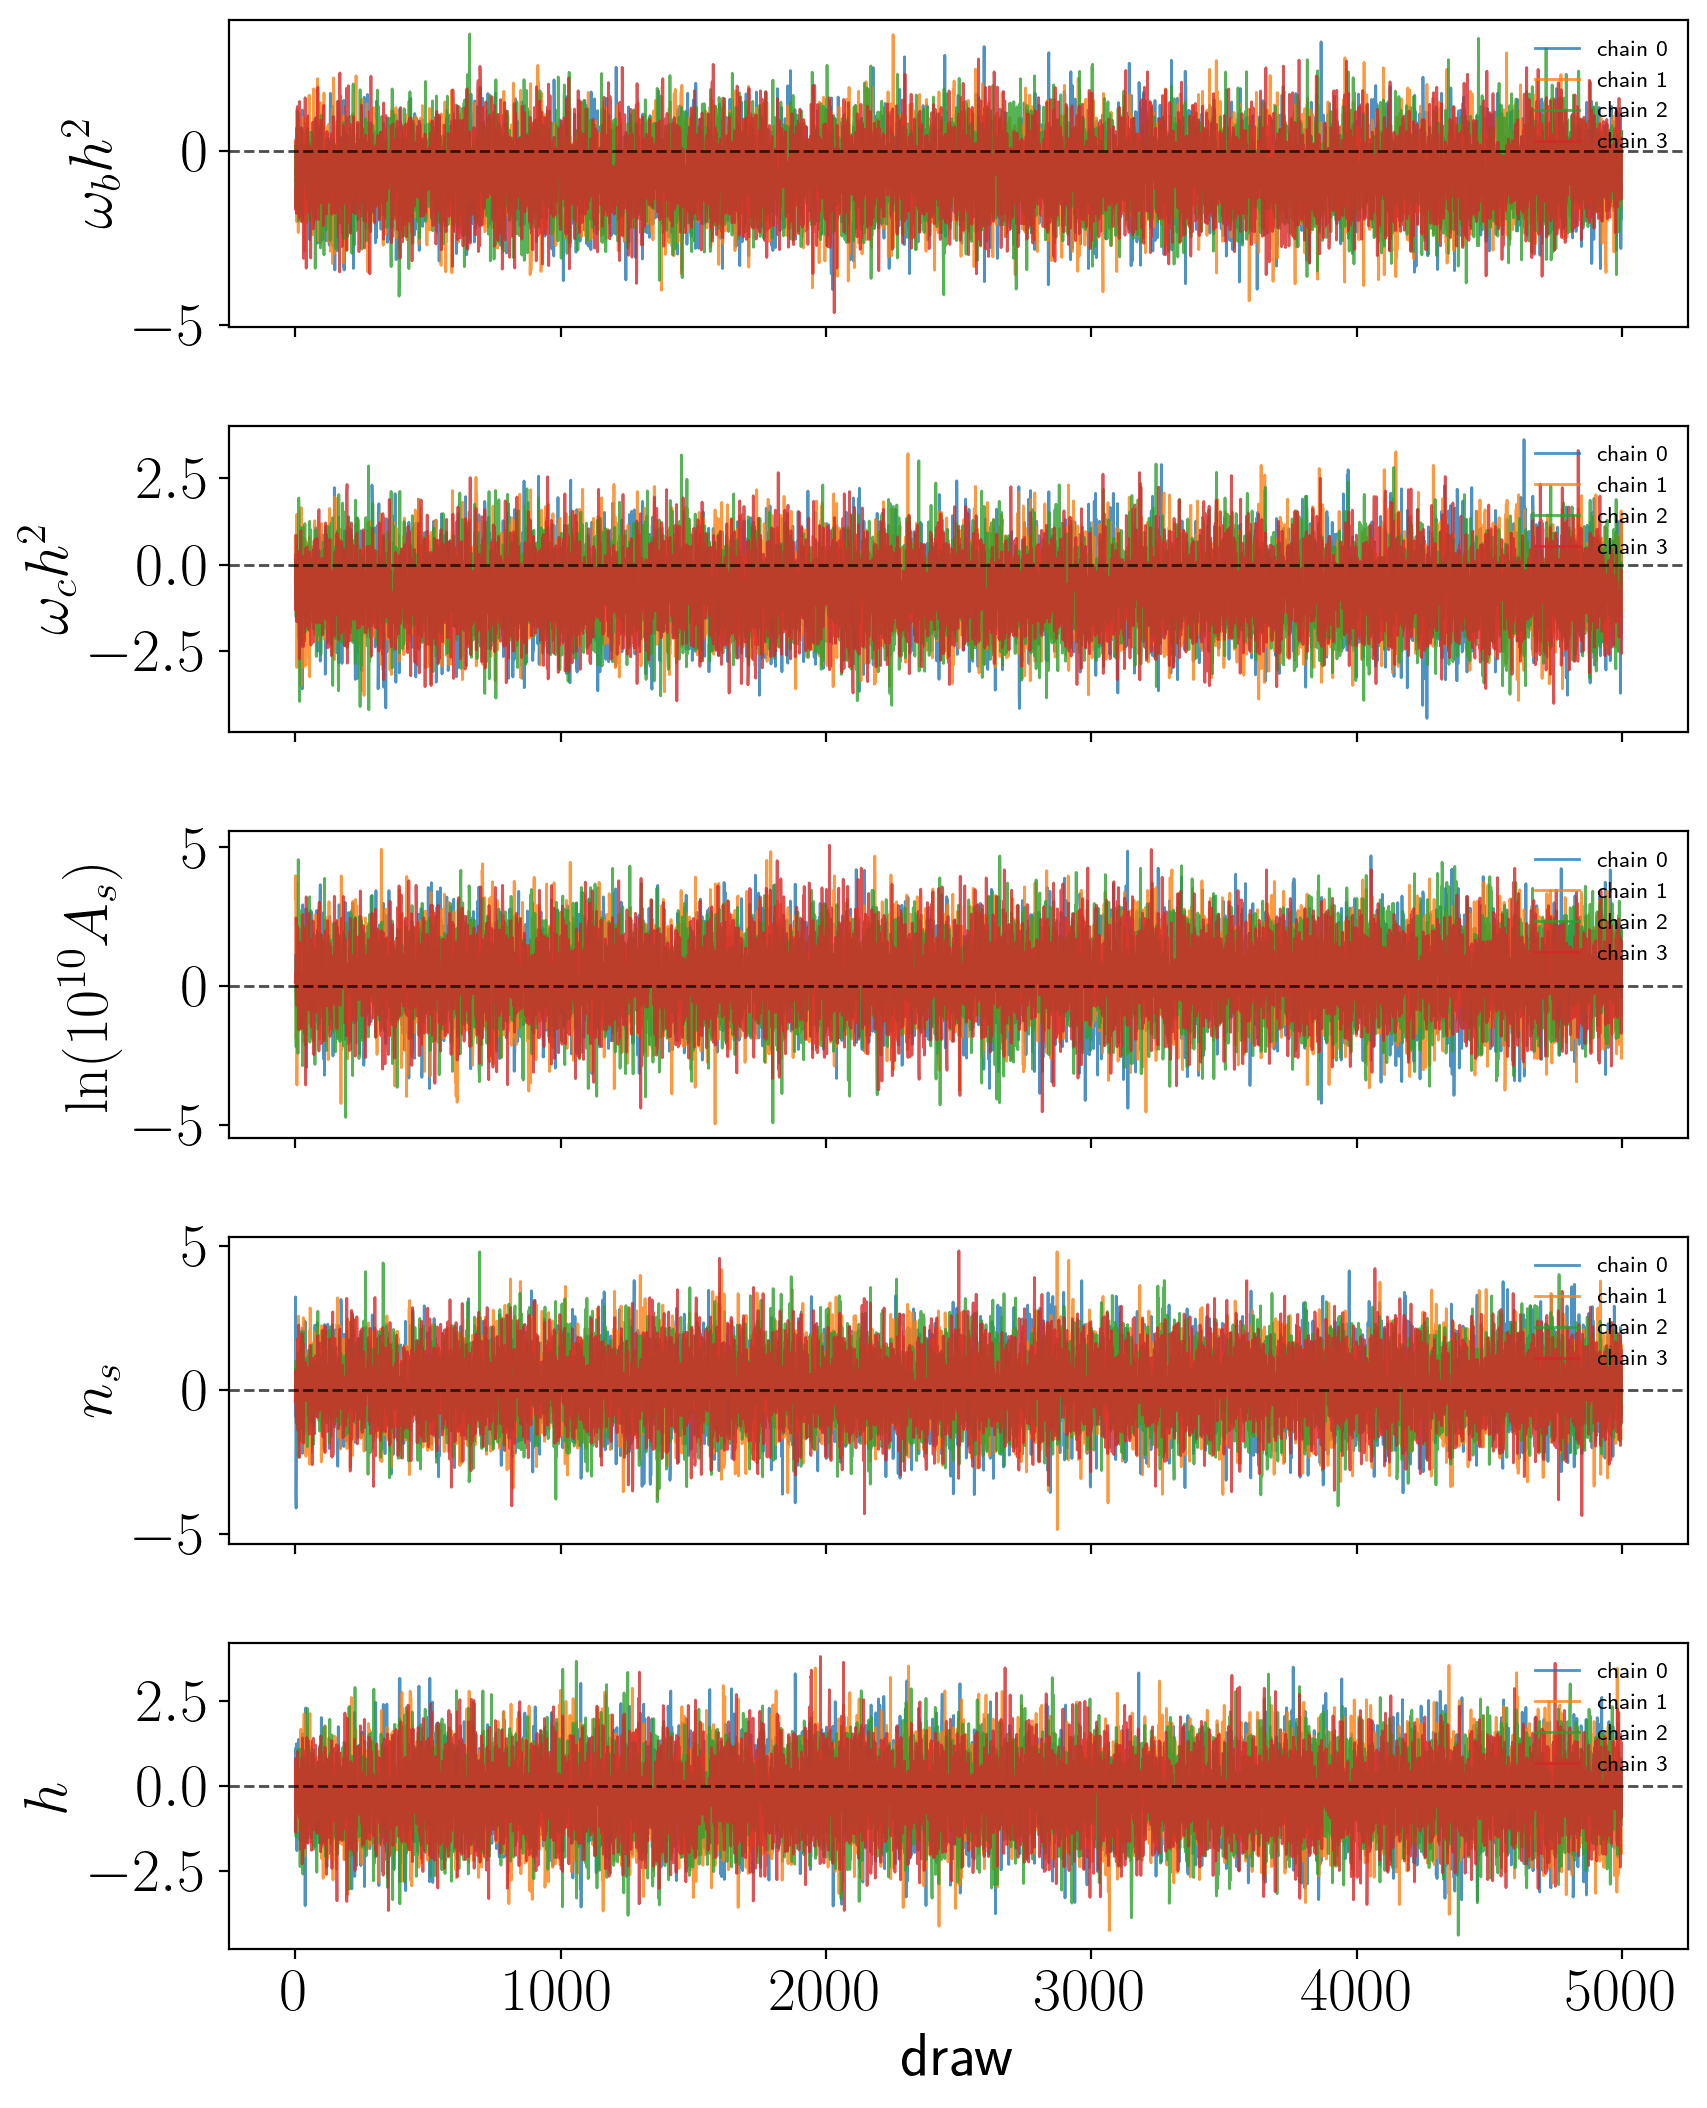

In [13]:
chain_spec = make_fullshape_spec(
    cosmo_keys=cosmo.param_keys, cosmo_sizes=cosmo.param_sizes, survey_keys=joint_survey_keys,
    n_bins=n_zbins, varied_idx=list(split.nl_idx), analysis_kind='joint')
named_w = packed_samples_to_dict(samples_w, chain_spec, chain_axis=0, draw_axis=1)
cosmo_names = [chain_spec.varied_param_names()[i] for i in cosmo_nl_pos]
cosmo_w = {name: named_w[name] for name in cosmo_names}
fig, _ = plot_trace(cosmo_w, var_names=cosmo_names,
                    truths={name: 0.0 for name in cosmo_names},
                    chain_axis=0, draw_axis=1)

## Physical-space posterior and MCMC-vs-Fisher comparison (cosmology)

The Fisher matrix compared against below (`F_pfs_bao_prior_cosmo`) carries the **same DESI
DR1-reanalysis priors + BBN/$n_{s,10}$** as the sampled target, and is built exactly as in
`fisher_joint_PFS_BAO_BBN_ns_LCDM.ipynb` — its σ's should reproduce that notebook's
"PFS P+B+BAO+BBN+ns" column. Read the ratio column with the mean-vs-mode caveat above.

> **In the committed state (`SMOKE_TEST=True`) the numbers below come from the 50-draw
> exact-path smoke chain**: a pipeline check, not a converged posterior — the σ ratios are
> dominated by sampling noise.

For exact-target confirmation of these surrogate posteriors, the delayed-acceptance MH chain in `scripts/damh_exact_chain_lcdm.py` samples the exact per-bin posterior directly, and importance-sampling reweighting diagnostics (`ess`, `ess_frac`, `max_weight`) that re-weight a surrogate chain back onto the exact posterior live in `jaxptpolypol.marginal_taylor` (`importance_reweight`, `reweighted_moments`).


In [14]:
samples_phys = samples_to_physical(samples_w, to_physical)
summary = scalar_summary_packed(samples_phys, chain_spec)

cosmo_flat = np.asarray(samples_phys)[..., cosmo_nl_pos].reshape(-1, N_SHARED)
mcmc_mean = cosmo_flat.mean(axis=0)
mcmc_sigma = cosmo_flat.std(axis=0)
mcmc_cov = np.cov(cosmo_flat, rowvar=False)
fisher_cov = np.asarray(inv(F_pfs_bao_prior_cosmo))   # DESI-spec priors = the target's spec
fisher_sig = np.sqrt(np.diag(fisher_cov))

print("Fisher: PFS P+B + DESI DR2 BAO + BBN/ns10 + DESI DR1-reanalysis EFT priors "
      "(same spec as the sampled target)")
if SMOKE_TEST:
    print(f"!! SMOKE_TEST: {cosmo_flat.shape[0]} draws from the exact-path gate chain -- "
          "the MCMC columns are noise, not a converged posterior.")
print(f"{'param':>7s} {'fid':>10s} {'MCMC mean':>12s} {'Fisher sig':>12s} {'MCMC sig':>12s} {'ratio':>7s}")
for i, key in enumerate(SHARED_KEYS):
    print(f"{key:>7s} {FIDUCIAL_SHARED[i]:10.5g} {mcmc_mean[i]:12.5g} "
          f"{fisher_sig[i]:12.5g} {mcmc_sigma[i]:12.5g} {mcmc_sigma[i]/fisher_sig[i]:7.2f}")

# Residual mean pull relative to Fisher sigma: (MCMC mean - fiducial) / Fisher sig.
# Under fiducial_centered the prior-mean gradient is removed, so this pull is the
# residual VOLUME term (logdet + width-volume + marginal curvature) only.
pulls = (mcmc_mean - FIDUCIAL_SHARED) / fisher_sig
print("residual pulls (volume term only under fiducial_centered): "
      + "  ".join(f"{key}={pulls[i]:+.2f}" for i, key in enumerate(SHARED_KEYS)))

Fisher: PFS P+B + DESI DR2 BAO + BBN/ns10 + DESI DR1-reanalysis EFT priors (same spec as the sampled target)
  param        fid    MCMC mean   Fisher sig     MCMC sig   ratio
  ombh2    0.02242     0.022119   0.00048211   0.00047985    1.00
  omch2    0.11933      0.11669     0.003422    0.0032185    0.94
   logA      3.047       3.0819     0.062477     0.060783    0.97
     ns     0.9665      0.97856     0.027963     0.027632    0.99
      h     0.6766      0.67368    0.0036491    0.0035686    0.98
residual pulls (volume term only under fiducial_centered): ombh2=-0.62  omch2=-0.77  logA=+0.56  ns=+0.43  h=-0.80


## Frequentist cross-check: profile likelihood peaks at fiducial

The marginal means above sit $0.4$–$0.9\,\sigma_F$ off fiducial. A profile likelihood isolates whether that is a *fitting* error or a *marginalization* artefact. Where the Bayesian marginal integrates the joint posterior over all other parameters, the profile instead **minimizes** the data $\chi^2$ over them: at each fixed value of one cosmological parameter we re-optimize every other $\theta_{\rm NL}$ dimension and analytically profile out the 11 linear EFT/stochastic amplitudes per bin (an exact whitened GLS, no priors). Because the mock is *noiseless* — the data vector is exactly the fiducial theory, and the Taylor templates reconstruct that theory exactly at the expansion point — the profiled $\chi^2$ is $0$ at fiducial and non-negative everywhere, so its global minimum sits at fiducial *by construction*. The BAO and BBN($\omega_b$)+$n_{s,10}$ terms are external, fiducial-centered, data-like constraints: centered at truth they cannot move the peak, they only break degeneracies and keep the 1-D profiles well-conditioned. The marginal means nonetheless drift because the Bayesian mean carries a cosmology-dependent **marginalization volume**: the $\ln\det$ of the $\theta_{\rm NL}$-dependent nuisance-prior widths plus the projection of the non-Gaussian joint onto the cosmology subspace tilt the integrated posterior even when the likelihood ridge is flat along fiducial. The table and figure below make the contrast quantitative: profile-min offsets $\approx 0$ against marginal-mean pulls of $0.4$–$0.9\,\sigma_F$.

chi2_prof(fiducial) = 1.231e-23   (noiseless-mock exactness tripwire, expect < 1e-10)



  param   profile-min offset   marginal-mean pull   (units: sigma_F)
  ombh2               -0.000                -0.62
  omch2                0.001                -0.77
   logA                0.000                 0.56
     ns               -0.000                 0.43
      h                0.000                -0.80

[PASS] max |profile-min offset| = 0.001 sigma_F (< 0.1 tol) vs marginal-mean pulls |.| in [0.43, 0.80] sigma_F -- the likelihood peaks at fiducial; the pulls are marginalization-volume effects.
profile computation wall time: 58.4 s


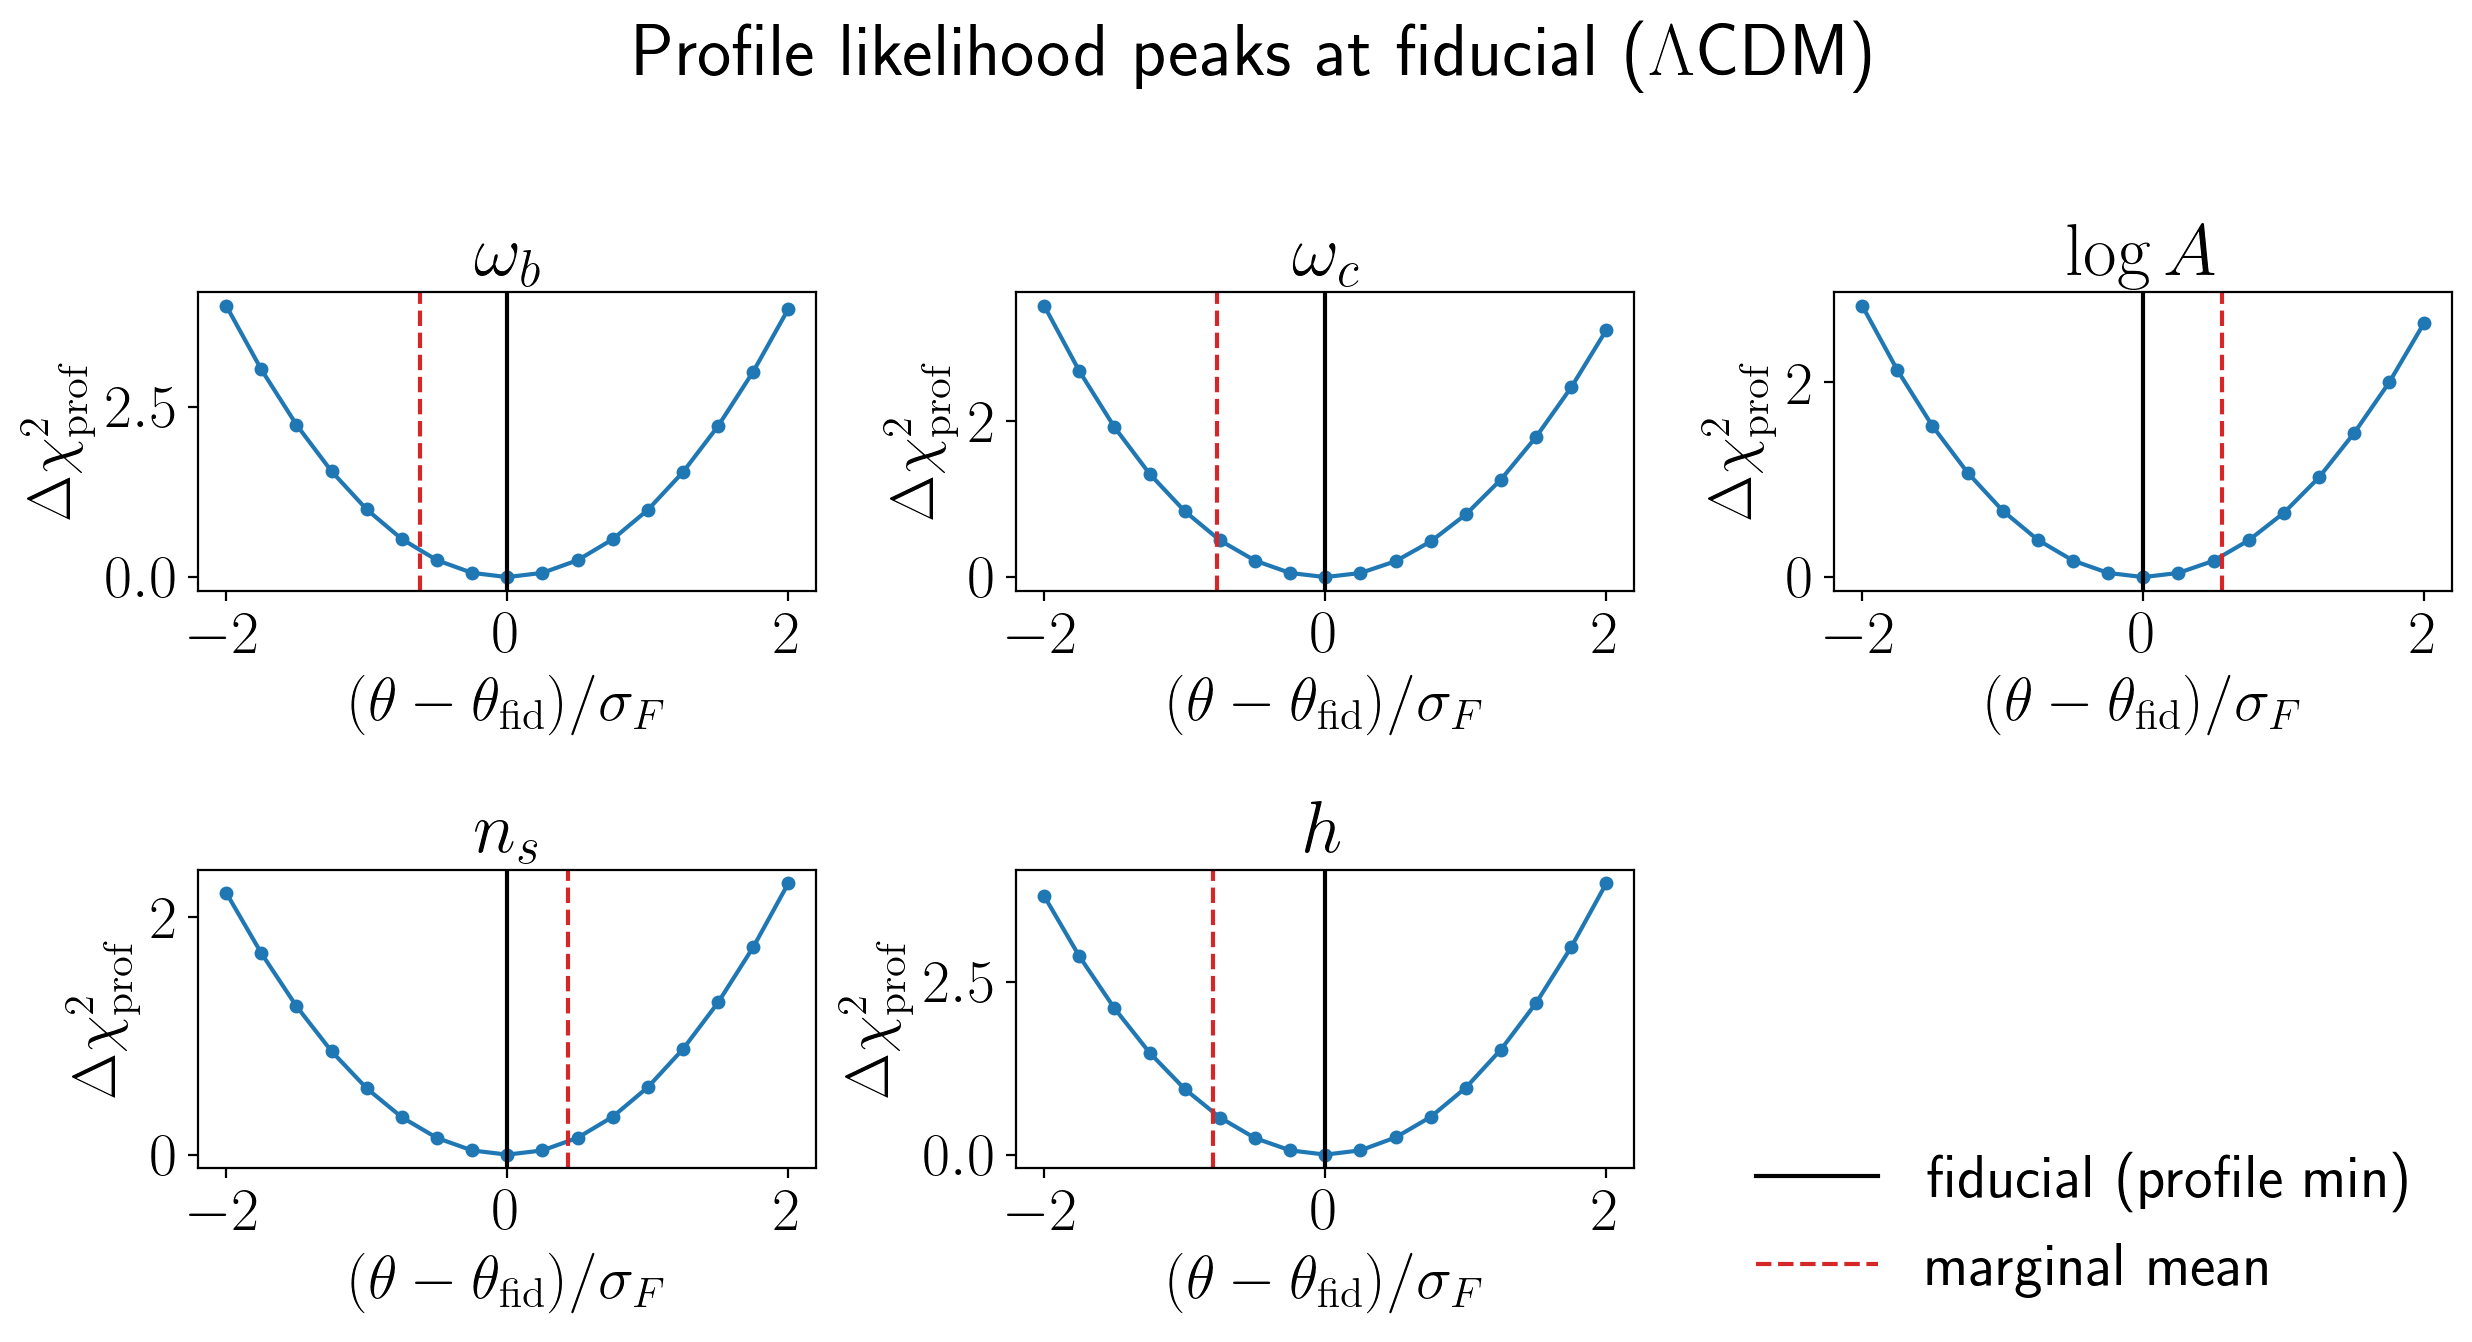

In [15]:
# ============================================================================
# Frequentist profile-likelihood check: the DATA likelihood peaks at fiducial
# ----------------------------------------------------------------------------
# Objective (DATA terms ONLY -- no theta_lin priors, no b1sigma8 Jacobian/[0,3]
# walls, no mnu prior): the profiled chi-square on the Taylor surrogate,
#   chi2_prof(theta_NL) = min_theta_lin ||W (d - m0(theta_NL) - M(theta_NL) theta_lin)||^2
#                         + chi2_BAO(theta_NL) + chi2_BBN_ns(theta_NL)
# The inner min over the 11 linear EFT/stochastic params per bin is an EXACT
# whitened GLS (per-bin W_b with W_b^T W_b = Cinv_b; solved by jnp.linalg.lstsq).
# BAO + BBN(ombh2) + ns10 are external, fiducial-centered, data-like constraints:
# centered at fiducial they cannot move the peak -- they only break degeneracies
# and keep the 1-D profiles well-conditioned. We reuse the notebook's own Taylor
# templates (_tt), whitened data (bin_data / bin_cov_invs), BAO term, and the
# BBN/ns10 entries (nl_prior_entries); no pipeline is rebuilt here.
from scipy.optimize import minimize

t_prof0 = time.time()

theta0_nl = jnp.asarray(_tt.theta0)                    # physical theta_NL fiducial (== fid_nl)
_order2 = _tt.order2_m0
# Per-bin whitening: Cinv_b = L L^T (lower Cholesky) => W_b = L^T, ||W_b r||^2 = r^T Cinv_b r.
W_bins = [jnp.linalg.cholesky(jnp.asarray(ci)).T for ci in bin_cov_invs]
bao_cov_inv_j = jnp.asarray(bao_cov_inv)
_nl_pos = jnp.array([int(e[0]) for e in nl_prior_entries])       # BBN(ombh2)+ns10 theta_NL positions
_nl_mu = jnp.array([float(e[1]) for e in nl_prior_entries])      # centered at fiducial
_nl_sig = jnp.array([float(e[2]) for e in nl_prior_entries])


@jax.jit
def chi2_prof(theta_nl):
    delta = theta_nl - theta0_nl
    chi2 = 0.0
    for b in range(len(W_bins)):
        m0 = _tt.bin_m00[b] + _tt.bin_J[b] @ delta
        if _order2:
            m0 = m0 + 0.5 * jnp.einsum("ijk,j,k->i", _tt.bin_H[b], delta, delta)
        M = _tt.bin_M0[b] + jnp.einsum("ijk,k->ij", _tt.bin_dM[b], delta)
        y = W_bins[b] @ (bin_data[b] - m0)             # whitened residual (theta_lin=0)
        X = W_bins[b] @ M                              # whitened template matrix
        sol = jnp.linalg.lstsq(X, y, rcond=None)[0]    # exact GLS profile-out of theta_lin
        res = y - X @ sol
        chi2 = chi2 + jnp.sum(res * res)
    # BAO (theta_lin-independent; evaluated on the full packed vector, fiducial-centered)
    r_bao = bao_fid - bao_theory_fn(full_params_fn(theta_nl)[:n_cosmo_params])
    chi2 = chi2 + r_bao @ bao_cov_inv_j @ r_bao
    # BBN(ombh2) + ns10 Gaussian data-like terms, centered at fiducial
    chi2 = chi2 + jnp.sum(((theta_nl[_nl_pos] - _nl_mu) / _nl_sig) ** 2)
    return chi2


# Exactness tripwire: the noiseless mock IS the fiducial theory and the templates
# reconstruct it exactly at the expansion point, so chi2_prof(fiducial) = 0 to the
# float64 floor; with chi2_prof >= 0 everywhere the global profile minimum is at
# fiducial BY CONSTRUCTION. The check's job is to show the 1-D profiles are smooth
# parabolas with minima at fiducial, in visible contrast to the pulled marginal means.
chi2_fid = float(jax.block_until_ready(chi2_prof(theta0_nl)))
print(f"chi2_prof(fiducial) = {chi2_fid:.3e}   (noiseless-mock exactness tripwire, expect < 1e-10)")
assert chi2_fid < 1e-10, f"profile objective not exact at fiducial: {chi2_fid}"

_val_and_grad = jax.jit(jax.value_and_grad(chi2_prof))
_theta0_np = np.asarray(theta0_nl)

has_mnu = 'mnu' in SHARED_KEYS
mnu_pos = cosmo_nl_pos[SHARED_KEYS.index('mnu')] if has_mnu else None
# Box every FREE cosmo dim to fid +/- K_BOX*sigma_F. This is a numerical validity
# safeguard, not a prior: the profile minimum is at fiducial (chi2 = 0) and the
# 1-D ridge stays within a few sigma_F, but the UNbounded optimizer can overshoot a
# free cosmo dim into a region where the background distance integral (bao_theory_fn)
# is undefined (NaN) -- exactly analogous to the mnu >= 0 emulator/surrogate validity
# bound. Bias dims never enter the background, so they are left free.
K_BOX = 6.0
cosmo_fid = {cosmo_nl_pos[m]: float(FIDUCIAL_SHARED[m]) for m in range(N_SHARED)}
cosmo_sig = {cosmo_nl_pos[m]: float(fisher_sig[m]) for m in range(N_SHARED)}

N_GRID = 5 if SMOKE_TEST else 17                        # coarse grid under SMOKE
prof_grids, prof_chi2_vals, prof_offsets = [], [], []

for i, key in enumerate(SHARED_KEYS):
    p_pos = cosmo_nl_pos[i]
    fid_i = float(FIDUCIAL_SHARED[i])
    sig_i = float(fisher_sig[i])
    if key == 'mnu':
        # mnu >= 0 is the emulator/surrogate VALIDITY domain (the unbounded-mnu
        # diagnostic proved mnu < 0 is a spurious extrapolation region), not a prior.
        grid = np.linspace(0.0, fid_i + 2.0 * sig_i, N_GRID)
    else:
        grid = np.linspace(fid_i - 2.0 * sig_i, fid_i + 2.0 * sig_i, N_GRID)

    free_pos = np.array([j for j in range(n_nl) if j != p_pos])
    bounds = []
    for j in free_pos:
        if j in cosmo_fid:                                 # box free cosmo dims (validity)
            lo = cosmo_fid[j] - K_BOX * cosmo_sig[j]
            hi = cosmo_fid[j] + K_BOX * cosmo_sig[j]
            if has_mnu and j == mnu_pos:
                lo = max(lo, 0.0)                          # mnu >= 0 validity domain
            bounds.append((lo, hi))
        else:
            bounds.append((None, None))                   # bias dims free

    def _scipy_obj(x_free, v, _fp=free_pos, _pp=p_pos):
        theta = _theta0_np.copy()
        theta[_fp] = x_free
        theta[_pp] = v
        val, g = _val_and_grad(jnp.asarray(theta))
        return float(val), np.asarray(g, dtype=np.float64)[_fp]

    chi2_vals = np.empty(N_GRID)
    kc = int(np.argmin(np.abs(grid - fid_i)))          # grid point nearest fiducial
    r = minimize(_scipy_obj, _theta0_np[free_pos], args=(grid[kc],),
                 method="L-BFGS-B", jac=True, bounds=bounds)
    chi2_vals[kc] = r.fun
    x_center = r.x
    x_prev = x_center                                   # warm-start outward (up) from the center
    for k in range(kc + 1, N_GRID):
        r = minimize(_scipy_obj, x_prev, args=(grid[k],), method="L-BFGS-B", jac=True, bounds=bounds)
        chi2_vals[k] = r.fun; x_prev = r.x
    x_prev = x_center                                   # warm-start outward (down) from the center
    for k in range(kc - 1, -1, -1):
        r = minimize(_scipy_obj, x_prev, args=(grid[k],), method="L-BFGS-B", jac=True, bounds=bounds)
        chi2_vals[k] = r.fun; x_prev = r.x

    # Locate the profile minimum by a parabola through the 3 points bracketing the smallest.
    km = int(np.argmin(chi2_vals))
    if 0 < km < N_GRID - 1:
        a2, a1, _ = np.polyfit(grid[km - 1:km + 2], chi2_vals[km - 1:km + 2], 2)
        x_min = (-a1 / (2.0 * a2)) if a2 > 0 else grid[km]
    else:
        x_min = grid[km]
    prof_grids.append(grid)
    prof_chi2_vals.append(chi2_vals)
    prof_offsets.append((x_min - fid_i) / sig_i)

prof_offsets = np.array(prof_offsets)
prof_wall = time.time() - t_prof0

# --- Table: profile-min offset vs marginal-mean pull (both in sigma_F) --------
print(f"\n{'param':>7s} {'profile-min offset':>20s} {'marginal-mean pull':>20s}   (units: sigma_F)")
for i, key in enumerate(SHARED_KEYS):
    print(f"{key:>7s} {prof_offsets[i]:>20.3f} {pulls[i]:>20.2f}")

max_off = float(np.max(np.abs(prof_offsets)))
min_pull = float(np.min(np.abs(pulls)))
# The PRODUCTION criterion is |offset| < 0.1 sigma_F at the 17-point grid (validated: the
# offsets are 0.001-0.01 sigma_F there). Under SMOKE the coarse grid cannot localize a
# BROAD profile's vertex (logA, mnu) to 0.1 sigma -- the parabola-through-3-grid-points
# estimate is grid-resolution limited -- so the smoke gate is loosened to 0.5 sigma. A
# broken profile (a NaN or a genuinely off-fiducial min -> argmin at a grid edge -> offset
# ~= 2 sigma) still trips it, so the smoke keeps its machinery-sanity value.
prof_tol = 0.5 if SMOKE_TEST else 0.1
profile_ok = max_off < prof_tol
print(f"\n[{'PASS' if profile_ok else 'FAIL'}] max |profile-min offset| = {max_off:.3f} sigma_F "
      f"(< {prof_tol} tol) vs marginal-mean pulls |.| in [{min_pull:.2f}, {float(np.max(np.abs(pulls))):.2f}] sigma_F "
      f"-- the likelihood peaks at fiducial; the pulls are marginalization-volume effects.")
print(f"profile computation wall time: {prof_wall:.1f} s")
assert profile_ok, (
    f"profile-min offset exceeds {prof_tol} sigma_F (max={max_off:.3f}); investigate optimizer "
    "convergence before loosening -- a converged violation falsifies the check's premise.")

# --- Figure: Delta chi2 profile per parameter (small multiples) ---------------
_ncol = 3
_nrow = int(np.ceil(N_SHARED / _ncol))
fig, axes = plt.subplots(_nrow, _ncol, figsize=(4.2 * _ncol, 3.4 * _nrow))
axes = np.atleast_1d(axes).ravel()
for i, key in enumerate(SHARED_KEYS):
    ax = axes[i]
    x_sig = (prof_grids[i] - float(FIDUCIAL_SHARED[i])) / float(fisher_sig[i])
    ax.plot(x_sig, prof_chi2_vals[i] - np.min(prof_chi2_vals[i]), 'o-', color='C0', ms=4)
    ax.axvline(0.0, color='k', ls='-', lw=1.5)                 # fiducial (profile peak)
    ax.axvline(pulls[i], color='C3', ls='--', lw=1.5)         # marginal mean
    ax.set_title(SHARED_LABELS[i])
    ax.set_xlabel(r'$(\theta-\theta_{\rm fid})/\sigma_F$')
    ax.set_ylabel(r'$\Delta\chi^2_{\rm prof}$')
for j in range(N_SHARED, len(axes)):
    axes[j].axis('off')
_solid = mlines.Line2D([], [], color='k', ls='-', lw=1.5, label='fiducial (profile min)')
_dash = mlines.Line2D([], [], color='C3', ls='--', lw=1.5, label='marginal mean')
fig.legend(handles=[_solid, _dash], loc='lower right', bbox_to_anchor=(0.98, 0.02), frameon=False)
fig.suptitle(rf'Profile likelihood peaks at fiducial ({MODEL_TITLE})', y=1.0)
fig.tight_layout()
plt.show()

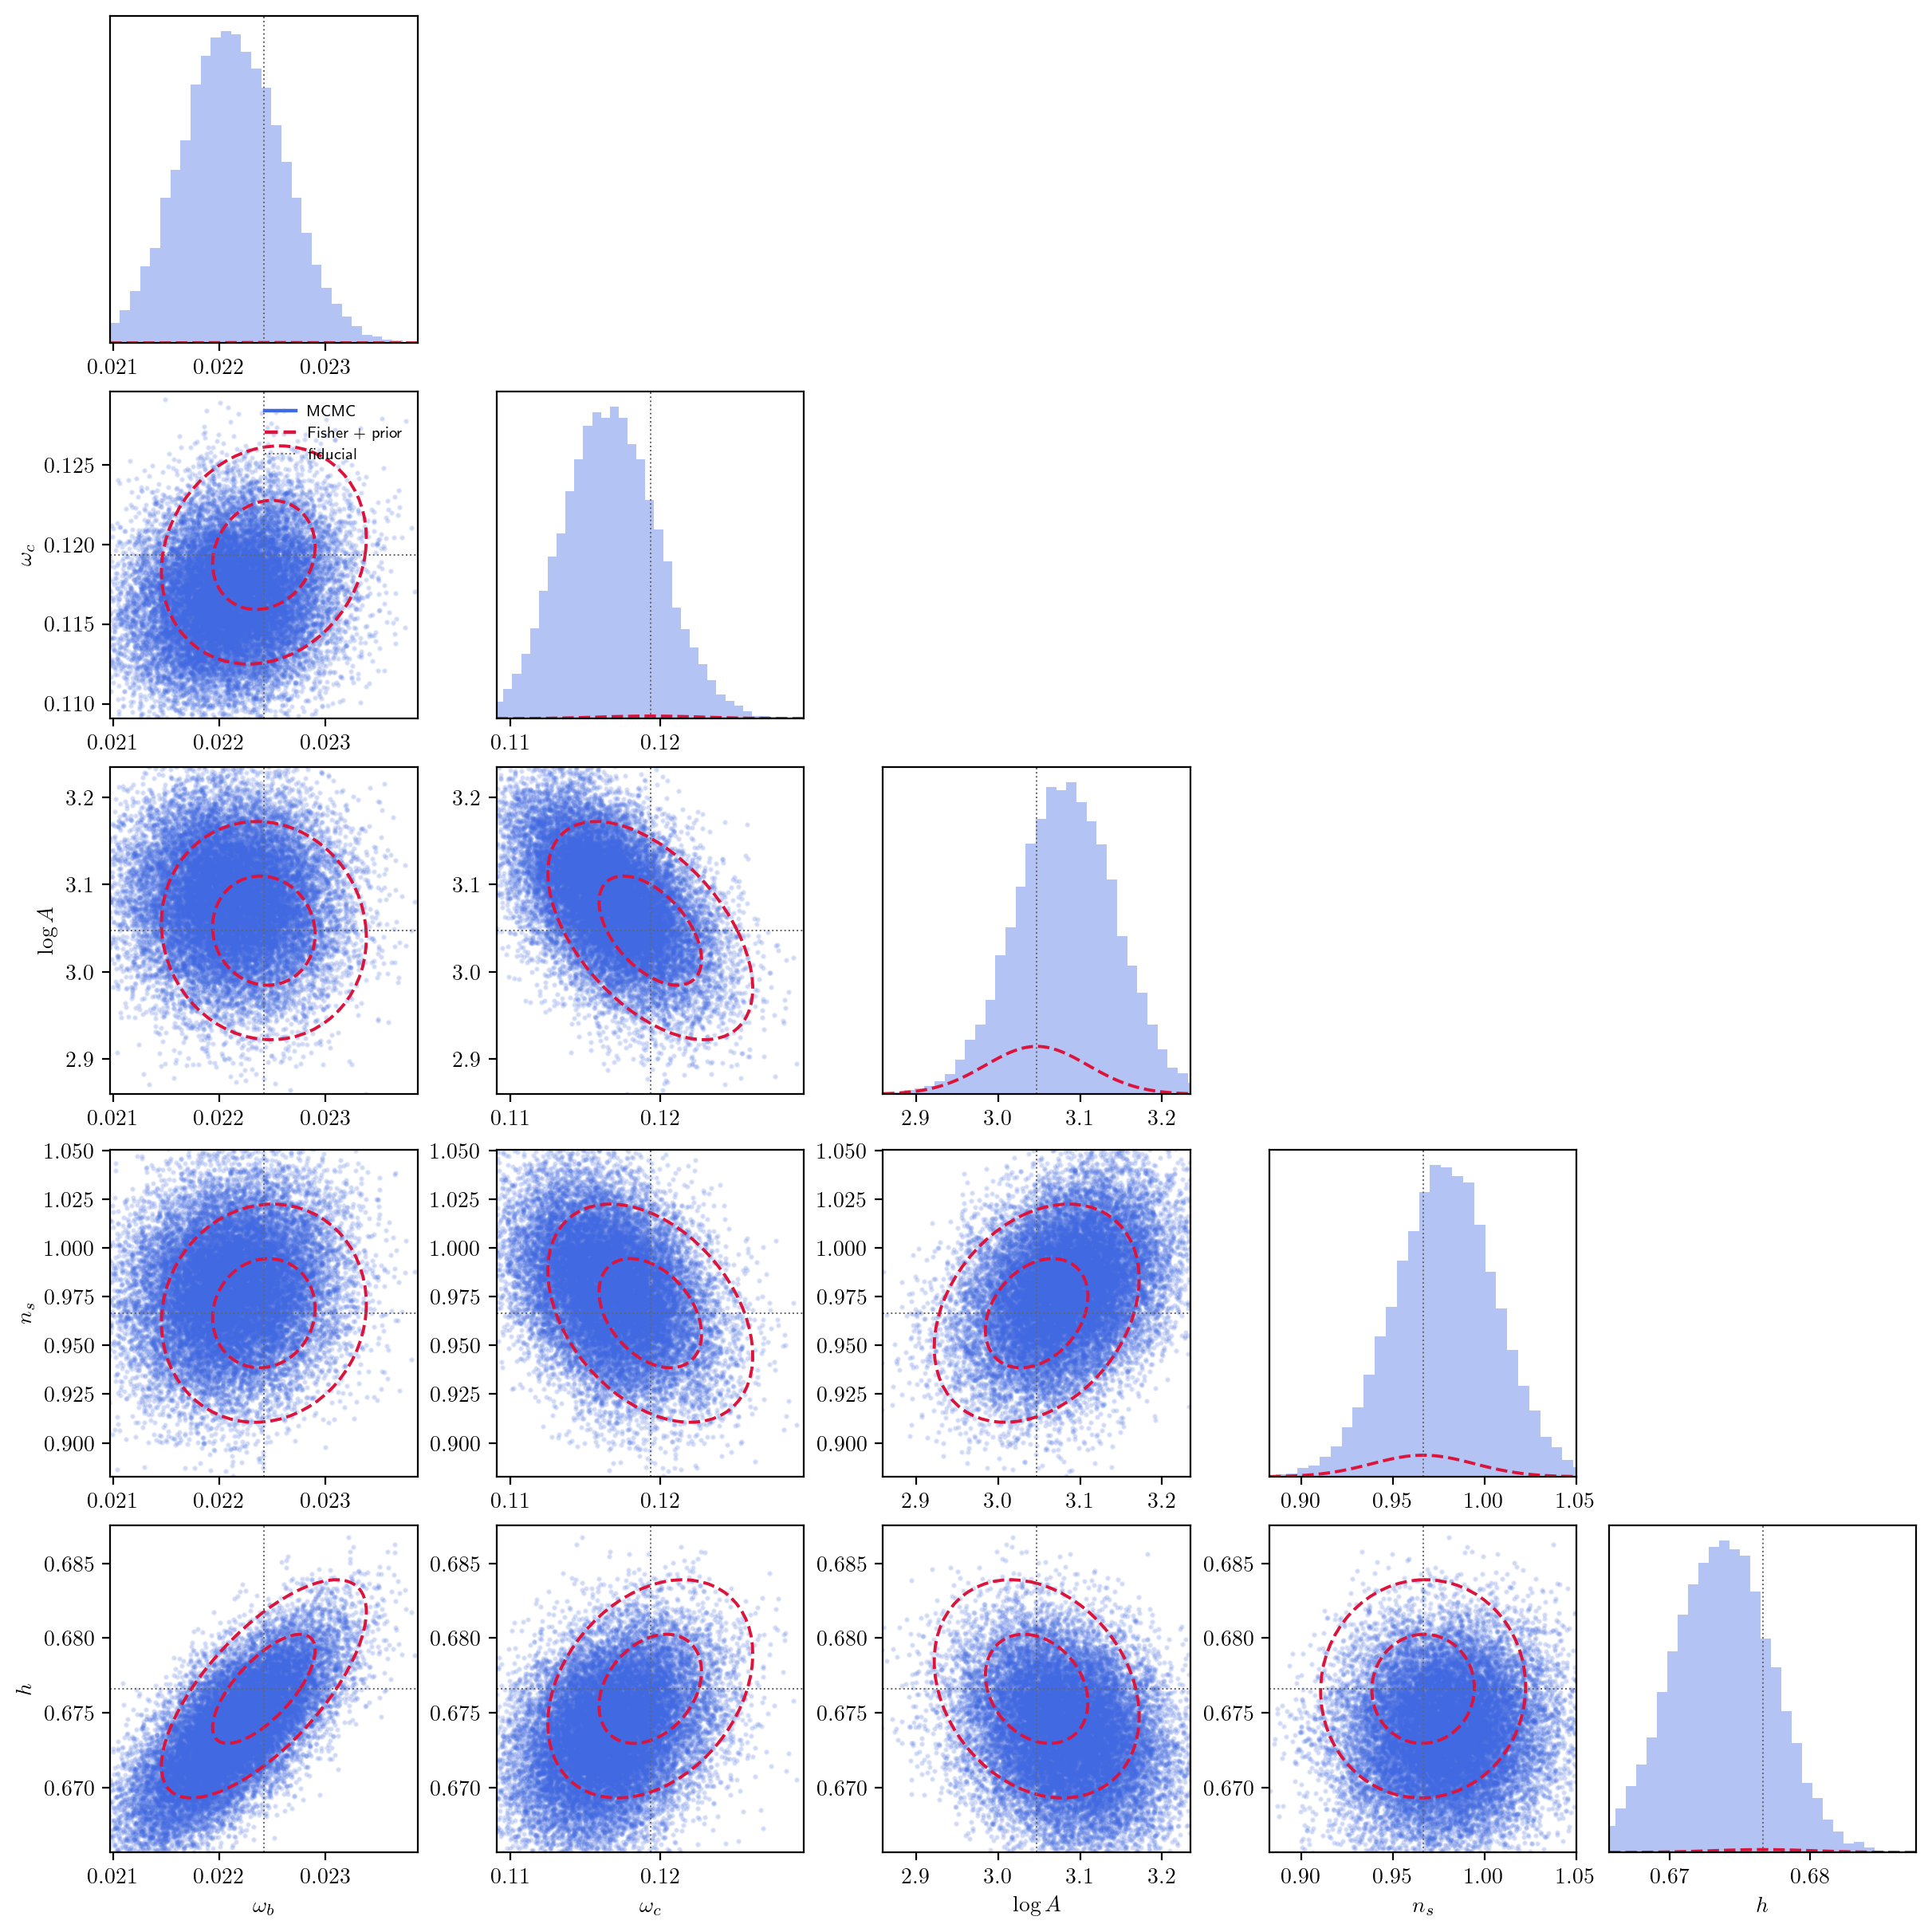

In [16]:
# Cosmology corner: MCMC samples (blue) vs Fisher+prior ellipses (red dashed), both at the
# fiducial. The Fisher ellipses use the DESI-spec comparison Fisher (the target's own priors).
plt.rcParams.update({"font.size": 10})
fig = plt.figure(figsize=(N_SHARED * 2.4, N_SHARED * 2.4), constrained_layout=True)
handles = [mlines.Line2D([], [], color='royalblue', lw=1.6, label='MCMC'),
           mlines.Line2D([], [], color='crimson', ls='--', lw=1.6, label='Fisher + prior'),
           mlines.Line2D([], [], color='0.4', lw=0.7, ls=':', label='fiducial')]
for i in range(N_SHARED):
    for j in range(N_SHARED):
        ax = plt.subplot(N_SHARED, N_SHARED, i * N_SHARED + j + 1)
        if j < i:
            ax.scatter(cosmo_flat[:, j], cosmo_flat[:, i], s=2, alpha=0.15,
                       color='royalblue', rasterized=True)
            plot_contours(F_pfs_bao_prior_cosmo, FIDUCIAL_SHARED, np.array([j, i]),
                          ax=ax, fill=False, color='crimson', ls='--', lw=1.4)
            ax.axvline(FIDUCIAL_SHARED[j], color='0.4', lw=0.7, ls=':')
            ax.axhline(FIDUCIAL_SHARED[i], color='0.4', lw=0.7, ls=':')
            if i == 1 and j == 0:
                ax.legend(handles=handles, fontsize=7, frameon=False, loc='best')
        elif j == i:
            ax.hist(cosmo_flat[:, i], bins=40, density=True, color='royalblue', alpha=0.4)
            plot_Gaussian(F_pfs_bao_prior_cosmo, FIDUCIAL_SHARED, i, ax=ax, color='crimson', ls='--', lw=1.4)
            ax.axvline(FIDUCIAL_SHARED[i], color='0.4', lw=0.7, ls=':')
            ax.set_yticks([])
        else:
            ax.axis('off')
        if i == N_SHARED - 1: ax.set_xlabel(SHARED_LABELS[j])
        if j == 0 and i > 0: ax.set_ylabel(SHARED_LABELS[i])

## Derived-parameter projection: $(\Omega_m, \sigma_8, H_0)$

The sampled cosmology is native -- $(\omega_b, \omega_c, \log A, n_s, h)$ -- while forecasts are usually quoted in the
derived basis $(\Omega_m, \sigma_8, H_0)$. Both the chain and the comparison Fisher are pushed through **one**
differentiable map, `jaxptpolypol.derived.make_lcdm_derived_params_fn` (the same helper the
`fisher_joint_*` notebooks project with), so the sample clouds and the Fisher ellipses below
cannot disagree by construction. $\Omega_m = (\omega_b + \omega_c + \Sigma m_\nu / 93.14)/h^2$ and
$H_0 = 100\,h$ are exact identities (asserted at the fiducial); $\sigma_8$ is the $z = 0$ top-hat
variance of the emulator's linear $P(k)$ and is printed, not asserted.

The MCMC columns are the sample mean/std of the projected chain. The Fisher column is
$\sqrt{\mathrm{diag}(J C J^{\mathsf{T}})}$ with $C$ the native comparison covariance
(`F_pfs_bao_prior_cosmo`) and $J$ the map's Jacobian at the fiducial. Native parameters that do not enter
the map (the per-bin bias block and the analytically marginalized $\theta_{\rm lin}$) are marginalized simply by being absent from it -- their correlations still
propagate through $C$.


derived fiducial: Omega_m = 0.311049, sigma8 = 0.810384, H0 = 67.6600  (sigma8 = z=0 top-hat variance of the emulator P_lin)

Derived basis: Omega_m , sigma8 , H0  |  Fisher = F_pfs_bao_prior_cosmo projected through the same map
    param        fid    MCMC mean   Fisher sig     MCMC sig   ratio
  Omega_m    0.31105      0.30726    0.0070463    0.0067088    0.95
   sigma8    0.81038      0.81791     0.023876     0.024277    1.02
       H0      67.66       67.368      0.36491      0.35686    0.98
residual pulls (sigma_F units): Omega_m=-0.54  sigma8=+0.32  H0=-0.80


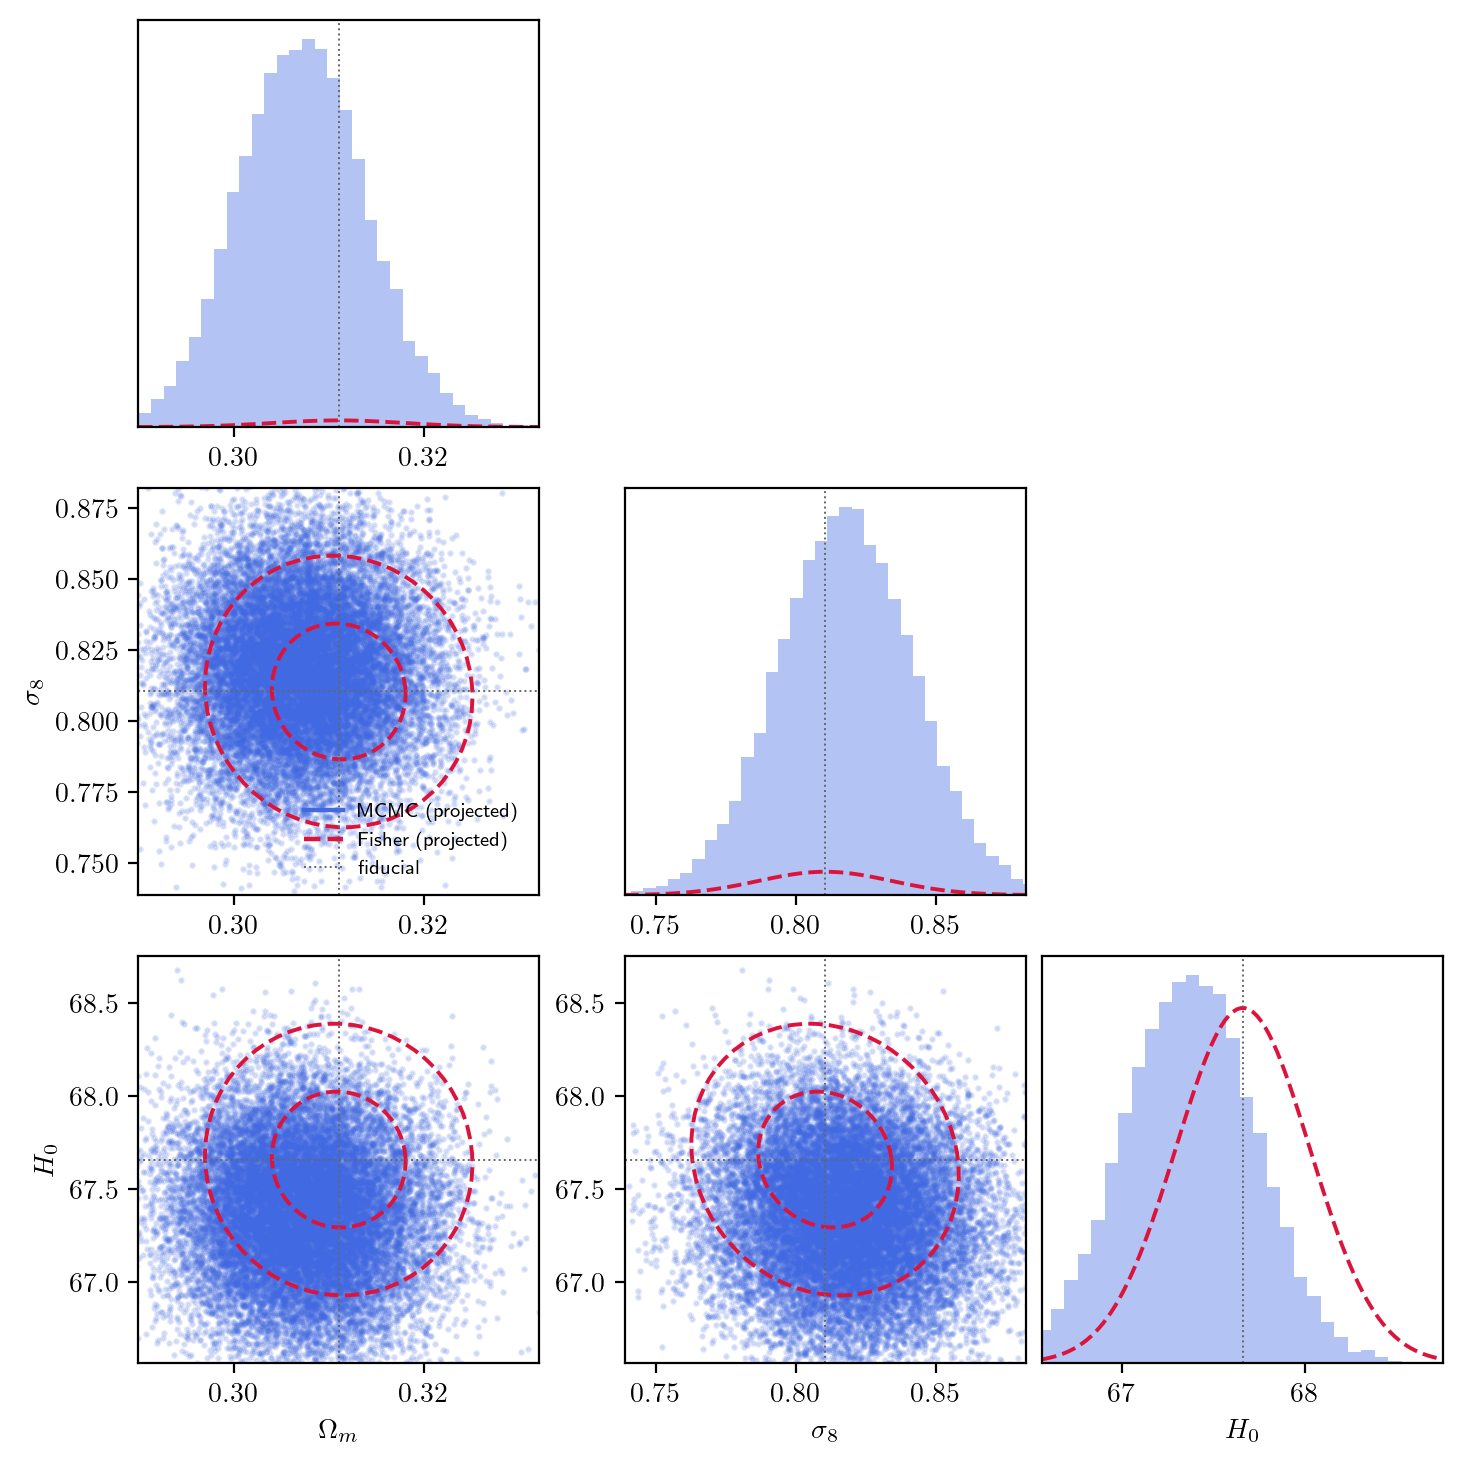

In [17]:
# ── Derived-parameter projection: (Omega_m, sigma8, H0) ──────────────────────
# ONE differentiable map carries BOTH the chain and the comparison Fisher into the
# derived basis, so the clouds and the ellipses below agree by construction. The
# library helper returns (Omega_m, H0, sigma8); the thin wrapper here reorders to the
# reported axis order. Native parameters absent from the wrapper (the bias block, theta_lin)
# are marginalized by simply not entering it, while their correlations still widen the
# projected covariance through C = F^-1.
from jaxptpolypol.derived import make_lcdm_derived_params_fn
from jaxptpolypol.inference import project_fisher_to_derived
from jaxptpolypol.cmb_mcmc_utils import chunked_map

DERIVED_NAMES  = ('Omega_m', 'sigma8', 'H0')
DERIVED_LABELS = (r'$\Omega_m$', r'$\sigma_8$', r'$H_0$')
DERIVED_SRC    = list(range(N_SHARED))   # positions in the comparison basis ...
DERIVED_NATIVE = list(cosmo_varied_global)   # ... -> slots of the native cosmo vector
assert len(DERIVED_SRC) == len(DERIVED_NATIVE)

_derived_core = make_lcdm_derived_params_fn(
    cosmo.param_keys, cosmo.param_sizes, pklin_emulator=pklin_emulator,
    mnu_fixed=MNU_FIXED, sigma8_redshift=0.0)          # sigma8 at z = 0
_fid_native = jnp.asarray(packed_params[:n_cosmo_params], dtype=jnp.float64)
_src_idx    = jnp.array(DERIVED_SRC)
_nat_idx    = jnp.array(DERIVED_NATIVE)

def derived_fn(theta):
    """Comparison-basis cosmology -> (Omega_m, sigma8, H0)."""
    native = _fid_native.at[_nat_idx].set(jnp.asarray(theta, dtype=jnp.float64)[_src_idx])
    Omega_m, H0, sigma8 = _derived_core(native)
    return jnp.array([Omega_m, sigma8, H0], dtype=jnp.float64)

# Chain -> derived (chunked; the emulator forward is a vectorized NN).
derived_flat  = chunked_map(cosmo_flat, jax.jit(jax.vmap(derived_fn)), chunk_size=20_000)
derived_mean  = derived_flat.mean(axis=0)
derived_sigma = derived_flat.std(axis=0)
assert np.all(np.isfinite(derived_flat)), "projected chain has non-finite entries"

# Comparison Fisher -> derived, through the SAME map.
F_derived, derived_fid, derived_jac, cov_derived = project_fisher_to_derived(
    F_pfs_bao_prior_cosmo, jnp.asarray(FIDUCIAL_SHARED), derived_fn)
fisher_sig_d = np.sqrt(np.diag(cov_derived))
assert np.all(np.isfinite(derived_jac)), "derived Jacobian has non-finite entries"
assert np.linalg.matrix_rank(derived_jac) == len(DERIVED_NAMES), "derived Jacobian is rank-deficient"

# Exact identities at the fiducial (analytic). sigma8 is emulator-derived -> printed only.
_nk  = list(cosmo.param_keys)
_ob  = float(_fid_native[_nk.index('ombh2')])
_oc  = float(_fid_native[_nk.index('omch2')])
_hh  = float(_fid_native[_nk.index('h')])
_mnf = float(_fid_native[_nk.index('mnu')]) if 'mnu' in _nk else float(MNU_FIXED)
_iOm, _is8, _iH0 = (DERIVED_NAMES.index(n) for n in ('Omega_m', 'sigma8', 'H0'))
assert abs(derived_fid[_iH0] - 100.0 * _hh) < 1e-12
assert abs(derived_fid[_iOm] - (_ob + _oc + _mnf / 93.14) / _hh**2) < 1e-12
print(f"derived fiducial: Omega_m = {derived_fid[_iOm]:.6f}, sigma8 = {derived_fid[_is8]:.6f}, "
      f"H0 = {derived_fid[_iH0]:.4f}  (sigma8 = z=0 top-hat variance of the emulator P_lin)")

print(f"\nDerived basis: {' , '.join(DERIVED_NAMES)}  |  Fisher = F_pfs_bao_prior_cosmo "
      "projected through the same map")
if SMOKE_TEST:
    print(f"!! SMOKE_TEST: {derived_flat.shape[0]} draws from the exact-path gate chain -- "
          "the MCMC columns are noise, not a converged posterior.")
print(f"{'param':>9s} {'fid':>10s} {'MCMC mean':>12s} {'Fisher sig':>12s} {'MCMC sig':>12s} {'ratio':>7s}")
for i, name in enumerate(DERIVED_NAMES):
    print(f"{name:>9s} {derived_fid[i]:10.5g} {derived_mean[i]:12.5g} "
          f"{fisher_sig_d[i]:12.5g} {derived_sigma[i]:12.5g} "
          f"{derived_sigma[i] / fisher_sig_d[i]:7.2f}")
pulls_d = (derived_mean - derived_fid) / fisher_sig_d
print("residual pulls (sigma_F units): "
      + "  ".join(f"{n}={pulls_d[i]:+.2f}" for i, n in enumerate(DERIVED_NAMES)))

# ── Derived-space corner: projected chain vs projected Fisher ───────────────
N_D = len(DERIVED_NAMES)
plt.rcParams.update({"font.size": 10})
fig = plt.figure(figsize=(N_D * 2.4, N_D * 2.4), constrained_layout=True)
handles = [mlines.Line2D([], [], color='royalblue', lw=1.6, label='MCMC (projected)'),
           mlines.Line2D([], [], color='crimson', ls='--', lw=1.6, label='Fisher (projected)'),
           mlines.Line2D([], [], color='0.4', lw=0.7, ls=':', label='fiducial')]
for i in range(N_D):
    for j in range(N_D):
        ax = plt.subplot(N_D, N_D, i * N_D + j + 1)
        if j < i:
            ax.scatter(derived_flat[:, j], derived_flat[:, i], s=2, alpha=0.15,
                       color='royalblue', rasterized=True)
            plot_contours(F_derived, derived_fid, np.array([j, i]),
                          ax=ax, fill=False, color='crimson', ls='--', lw=1.4)
            ax.axvline(derived_fid[j], color='0.4', lw=0.7, ls=':')
            ax.axhline(derived_fid[i], color='0.4', lw=0.7, ls=':')
            if i == 1 and j == 0:
                ax.legend(handles=handles, fontsize=7, frameon=False, loc='best')
        elif j == i:
            ax.hist(derived_flat[:, i], bins=40, density=True, color='royalblue', alpha=0.4)
            plot_Gaussian(F_derived, derived_fid, i, ax=ax, color='crimson', ls='--', lw=1.4)
            ax.axvline(derived_fid[i], color='0.4', lw=0.7, ls=':')
            ax.set_yticks([])
        else:
            ax.axis('off')
        if i == N_D - 1: ax.set_xlabel(DERIVED_LABELS[j])
        if j == 0 and i > 0: ax.set_ylabel(DERIVED_LABELS[i])
